# 🚗 Tesla Deliveries — Structured ML & Time Series Notebook
**Dataset:** Tesla EV Deliveries & Production Data (2015–2025)


| Section | Topics Covered |
|---|---|
| **1. Data Cleaning** | Nulls, duplicates, dtypes, outliers |
| **2. EDA** | Distributions, correlations, time trends |
| **3. Encoding Techniques** | Label Encoding, One-Hot Encoding |
| **4. Feature Scaling** | RobustScaler, StandardScaler comparison |
| **5. Feature Engineering** | Lag features, rolling statistics, cyclical encoding |
| **6. Data Leakage** | Identifying and preventing leakage |
| **7. Sklearn Pipeline** | Chaining preprocessing + model |
| **8. Chronological Split** | Time-aware train/test splitting |
| **9. Regression Models** | Linear · Ridge (L2) · Lasso (L1) |
| **10. Bias-Variance Tradeoff** | Learning curves, overfitting/underfitting |
| **11. Evaluation Metrics** | RMSE · MAE · MAPE · R² |
| **12. Cross Validation** | TimeSeriesSplit |
| **13. Hyperparameter Tuning** | GridSearchCV · RandomizedSearchCV |
| **14. Time Series Components** | Trend, Seasonality, Residuals |
| **15. Stationarity** | ADF test, differencing |
| **16. SARIMA Forecasting** | Fit, evaluate, forecast |

**Target variable:** `Estimated_Deliveries`


## 0 · Imports & Setup

In [98]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Sklearn — preprocessing
from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                   LabelEncoder, OneHotEncoder,
                                   PolynomialFeatures)
from sklearn.pipeline import Pipeline
from sklearn.compose  import ColumnTransformer

# Sklearn — models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Sklearn — evaluation & selection
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     TimeSeriesSplit, GridSearchCV,
                                     RandomizedSearchCV, learning_curve)
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, mean_absolute_percentage_error)

# Time series
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools          import adfuller
from statsmodels.tsa.seasonal           import seasonal_decompose
from statsmodels.graphics.tsaplots      import plot_acf, plot_pacf

# ── Plot style (Tesla-inspired) ────────────────────────────────
RED, DARK, BLUE, GOLD = "#E31937", "#171A20", "#5897FB", "#F5A623"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#FAFAFA",
    "axes.edgecolor":   "#CCC",  "axes.titlesize":  13,
    "axes.titleweight": "bold",  "axes.grid":       True,
    "grid.color":       "#E8E8E8","grid.linestyle": "--",
    "grid.linewidth":   0.6,     "figure.dpi":      110,
})
kfmt = mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k")
np.random.seed(42)
print("✅  All imports loaded.")


✅  All imports loaded.


## 1 · Data Cleaning

Data cleaning is the first step of any ML pipeline. We inspect:
- **Shape & dtypes** — understand what we're working with
- **Missing values** — decide to drop, impute, or flag
- **Duplicates** — prevent model bias from repeated rows
- **Outliers** — detect using IQR and Z-score methods


In [99]:
DATA_PATH = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
df_raw = pd.read_csv(DATA_PATH)
df     = df_raw.copy()

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes.to_string())


Shape : 2,640 rows × 12 columns

Column types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64


In [100]:
# ── 1.1 Missing values ────────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing >= 0].to_string())
print(f"\nTotal nulls: {missing.sum()}")


Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0

Total nulls: 0


In [101]:
# ── 1.2 Duplicates ────────────────────────────────────────────
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")
if dups > 0:
    df = df.drop_duplicates()
    print(f"  -> Removed. New shape: {df.shape}")
else:
    print("  -> No duplicates found. ✅")


Duplicate rows: 0
  -> No duplicates found. ✅


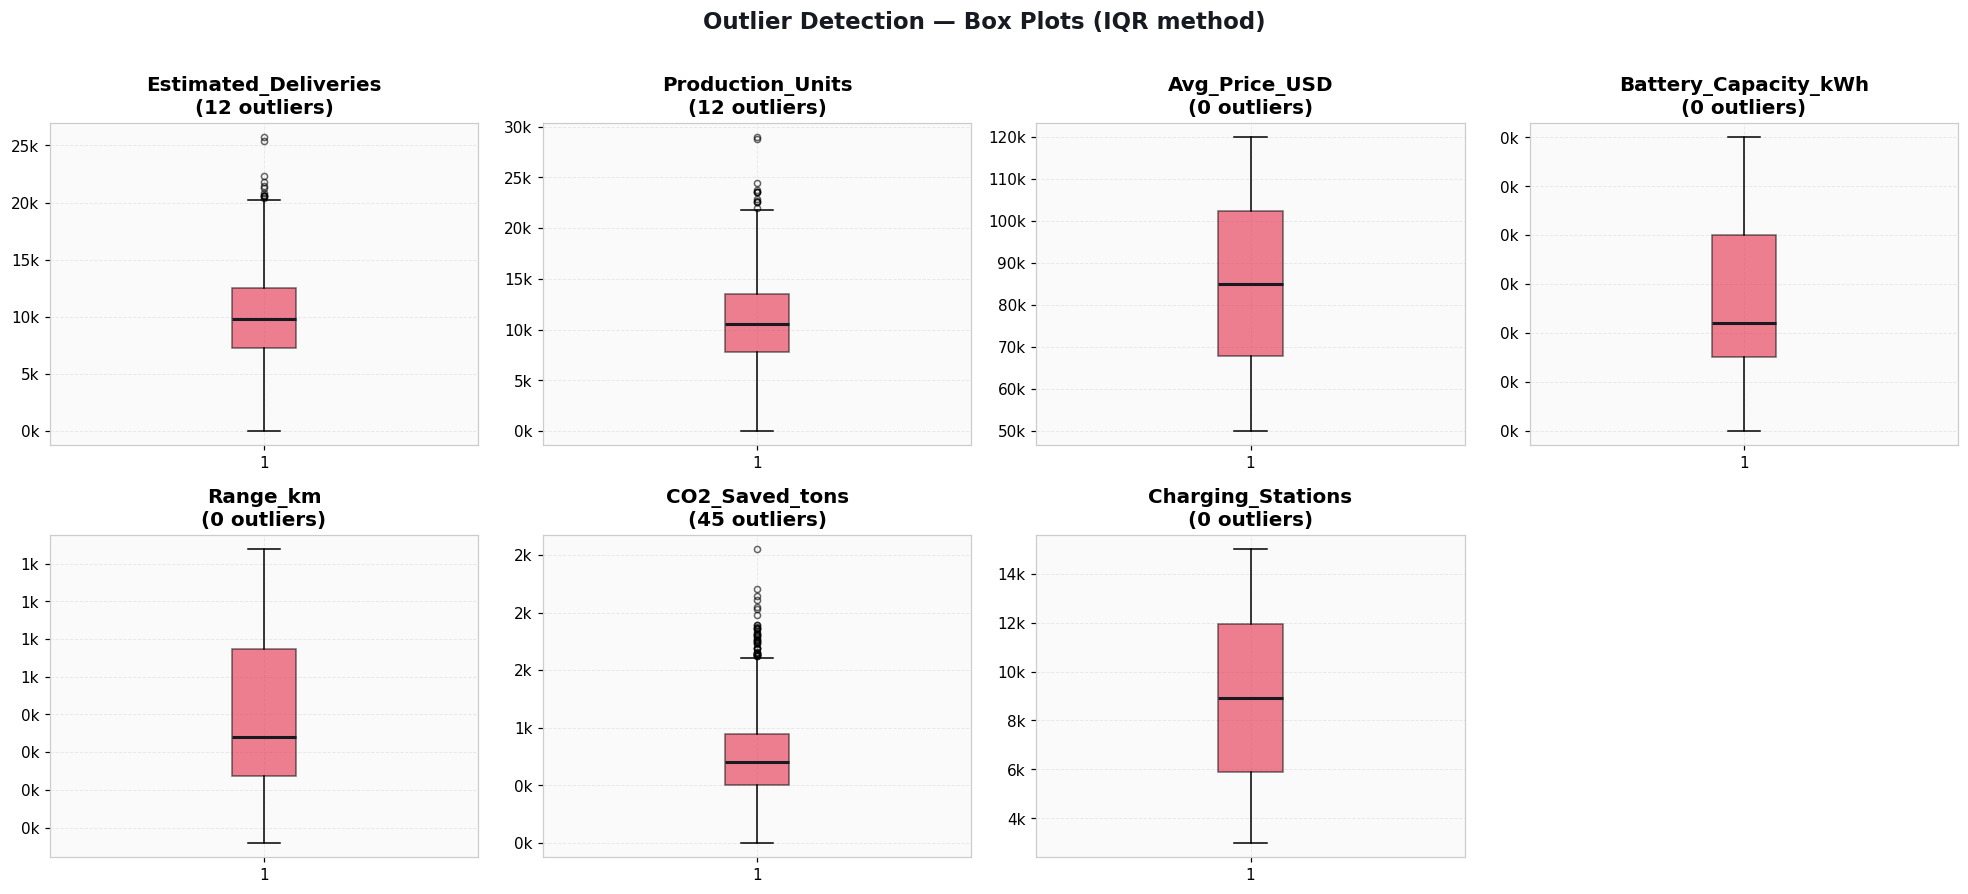


Outlier Summary:


,Q1,Q3,IQR,Lower fence,Upper fence,Outliers
Estimated_Deliveries,7292.00,12510.25,5218.25,-535.38,20337.62,12.0
Production_Units,7828.25,13469.00,5640.75,-632.88,21930.12,12.0
Avg_Price_USD,67726.36,102373.04,34646.68,15756.35,154343.06,0.0
Battery_Capacity_kWh,75.00,100.00,25.00,37.50,137.50,0.0
Range_km,418.00,586.25,168.25,165.62,838.62,0.0
CO2_Saved_tons,499.62,943.76,444.14,-166.60,1609.98,45.0
Charging_Stations,5897.75,11938.00,6040.25,-3162.62,20998.38,0.0


In [102]:
# ── 1.3 Outlier detection — IQR method ───────────────────────
NUM_COLS = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

outlier_report = {}
for i, col in enumerate(NUM_COLS):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {"Q1": Q1, "Q3": Q3, "IQR": IQR,
                            "Lower fence": lower, "Upper fence": upper,
                            "Outliers": n_out}
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=RED, alpha=0.55),
                    medianprops=dict(color=DARK, lw=2),
                    flierprops=dict(marker="o", color=BLUE,
                                    markersize=4, alpha=0.6))
    axes[i].set_title(f"{col}\n({n_out} outliers)")
    axes[i].yaxis.set_major_formatter(kfmt)

axes[-1].set_visible(False)
fig.suptitle("Outlier Detection — Box Plots (IQR method)",
             fontsize=15, fontweight="bold", color=DARK, y=1.01)
plt.tight_layout()
plt.show()

print("\nOutlier Summary:")
display(pd.DataFrame(outlier_report).T.round(2))


In [103]:
# ── 1.4 Z-score outlier check on main target ─────────────────
from scipy import stats

z_scores = np.abs(stats.zscore(df["Estimated_Deliveries"]))
z_thresh = 3
z_outliers = (z_scores > z_thresh).sum()
print(f"Z-score outliers (|z| > {z_thresh}) in Estimated_Deliveries: {z_outliers}")
print("Decision: KEEP — these are genuine extreme-quarter deliveries, not errors.")
print(f"\nCleaned dataset shape: {df.shape}")


Z-score outliers (|z| > 3) in Estimated_Deliveries: 4
Decision: KEEP — these are genuine extreme-quarter deliveries, not errors.

Cleaned dataset shape: (2640, 12)


## 2 · Exploratory Data Analysis (EDA)

EDA helps us understand patterns, distributions, and relationships before modelling.
We look at:
- **Univariate**: individual feature distributions
- **Bivariate**: feature vs target relationships  
- **Temporal**: how deliveries evolve over time


In [104]:
# ── 2.1 Descriptive statistics ────────────────────────────────
display(df.describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.00,3.16,2015.00,2017.00,2020.00,2023.00,2025.00
Month,2640.0,6.50,3.45,1.00,3.75,6.50,9.25,12.00
Estimated_Deliveries,2640.0,9922.20,3935.95,48.00,7292.00,9857.00,12510.25,25704.00
Production_Units,2640.0,10655.85,4260.60,50.00,7828.25,10546.50,13469.00,28939.00
Avg_Price_USD,2640.0,84907.34,20123.26,50003.70,67726.36,85058.51,102373.04,119965.36
Battery_Capacity_kWh,2640.0,87.06,20.84,60.00,75.00,82.00,100.00,120.00
Range_km,2640.0,500.26,120.87,330.00,418.00,470.00,586.25,719.00
CO2_Saved_tons,2640.0,744.08,353.22,3.07,499.62,699.52,943.76,2548.55
Charging_Stations,2640.0,8932.13,3469.57,3002.00,5897.75,8901.50,11938.00,14996.00


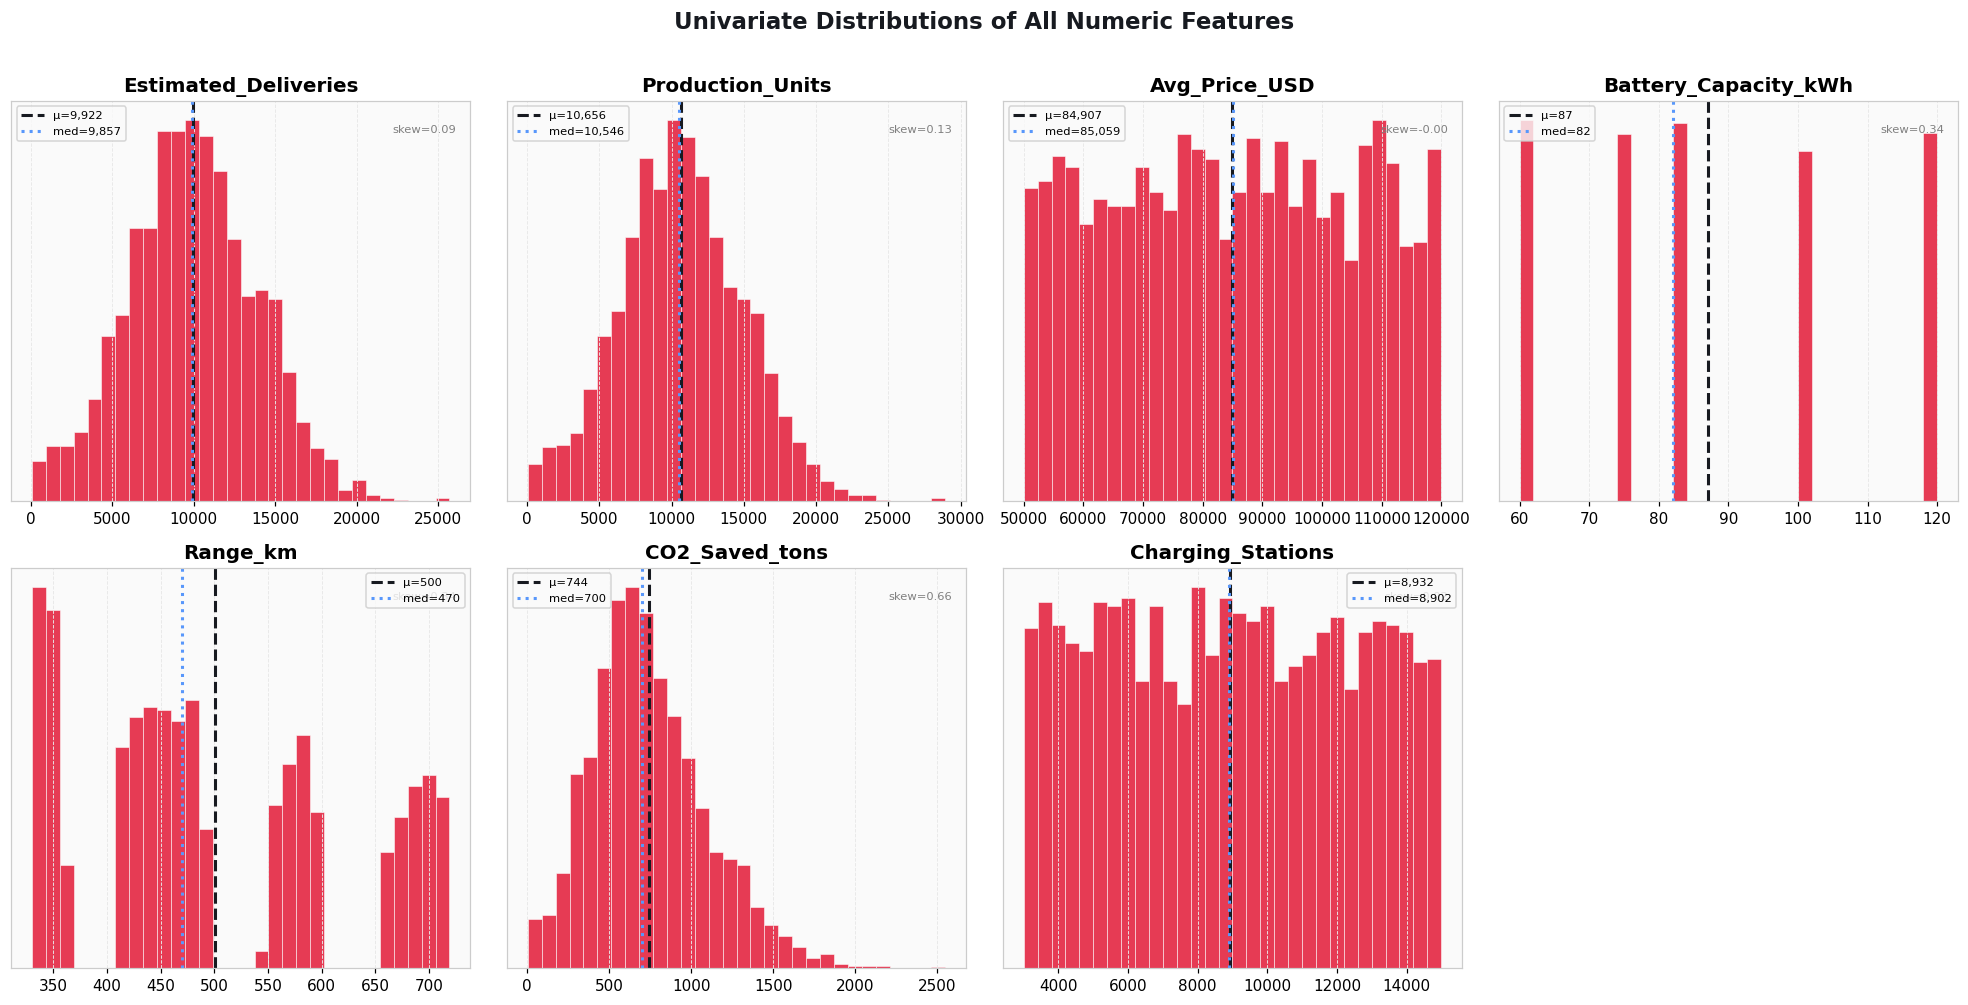

In [105]:
# ── 2.2 Univariate distributions ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    ax   = axes[i]
    data = df[col]
    ax.hist(data, bins=30, color=RED, edgecolor="white",
            alpha=0.85, linewidth=0.4)
    ax.axvline(data.mean(),   color=DARK, lw=2, linestyle="--",
               label=f"μ={data.mean():,.0f}")
    ax.axvline(data.median(), color=BLUE, lw=2, linestyle=":",
               label=f"med={data.median():,.0f}")
    ax.set_title(col)
    ax.legend(fontsize=7.5)
    ax.yaxis.set_visible(False)
    ax.text(0.97, 0.92, f"skew={data.skew():.2f}",
            transform=ax.transAxes, ha="right", fontsize=7.5, color="gray")

axes[-1].set_visible(False)
fig.suptitle("Univariate Distributions of All Numeric Features",
             fontsize=15, fontweight="bold", color=DARK, y=1.01)
plt.tight_layout()
plt.show()


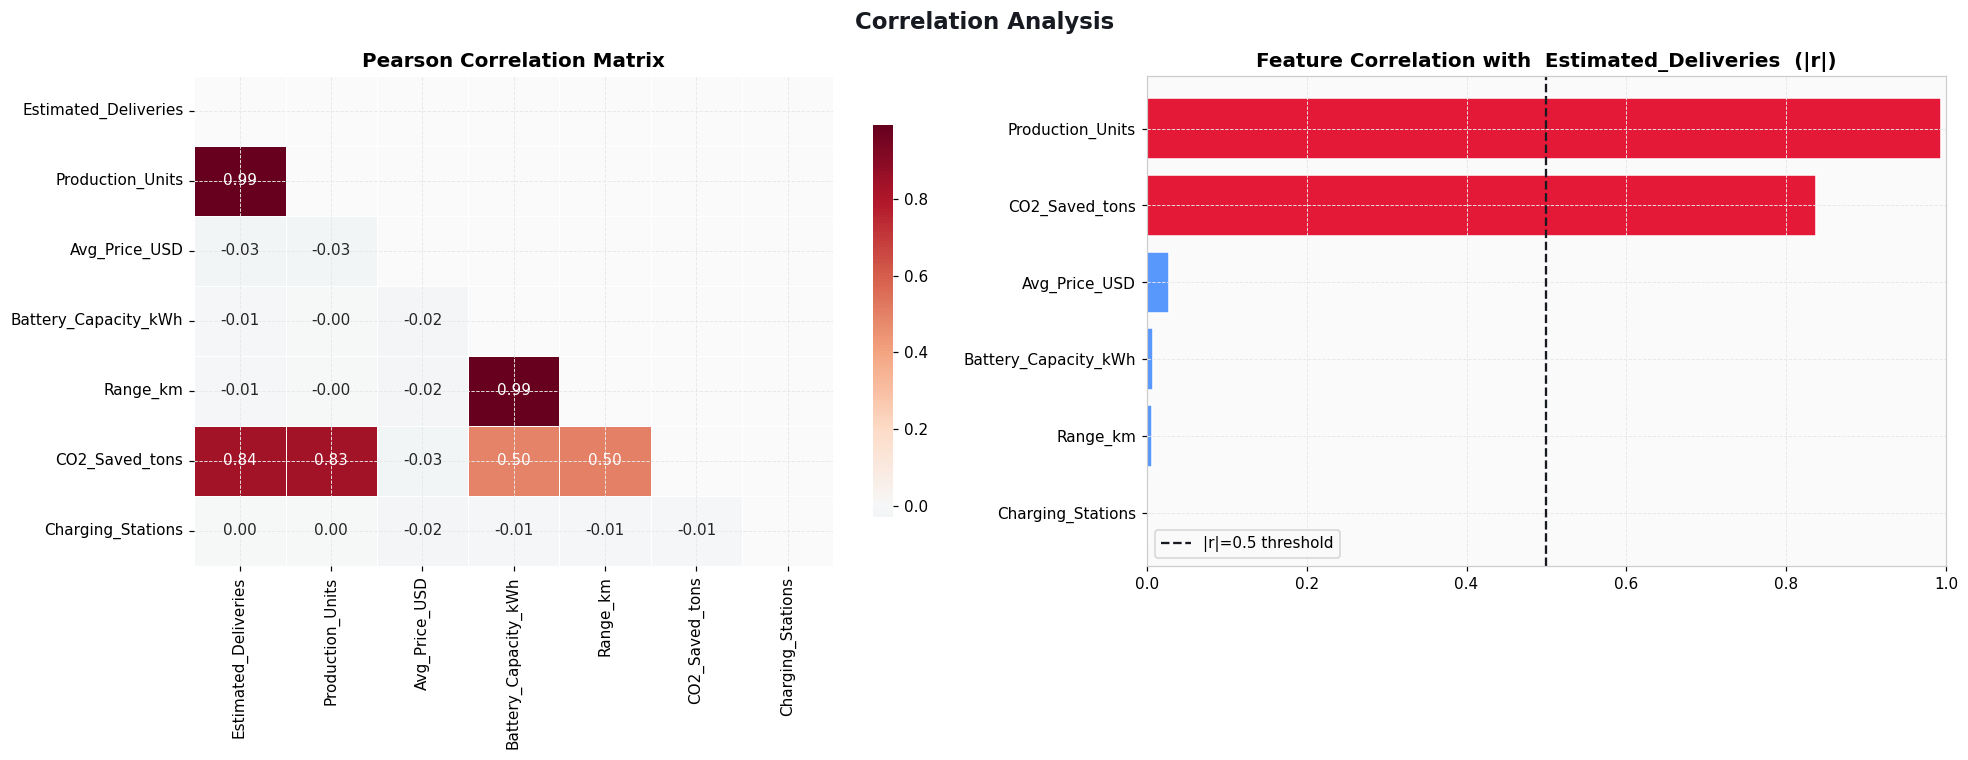

In [106]:
# ── 2.3 Correlation heatmap ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[0], linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Pearson Correlation Matrix")

# Top correlators with target
corr_t = corr["Estimated_Deliveries"].drop("Estimated_Deliveries").abs().sort_values()
colors = [RED if v > 0.5 else BLUE for v in corr_t.values]
axes[1].barh(corr_t.index, corr_t.values, color=colors, edgecolor="white")
axes[1].set_title("Feature Correlation with  Estimated_Deliveries  (|r|)")
axes[1].set_xlim(0, 1)
axes[1].axvline(0.5, color=DARK, lw=1.5, linestyle="--", label="|r|=0.5 threshold")
axes[1].legend()

fig.suptitle("Correlation Analysis", fontsize=15, fontweight="bold", color=DARK)
plt.tight_layout()
plt.show()


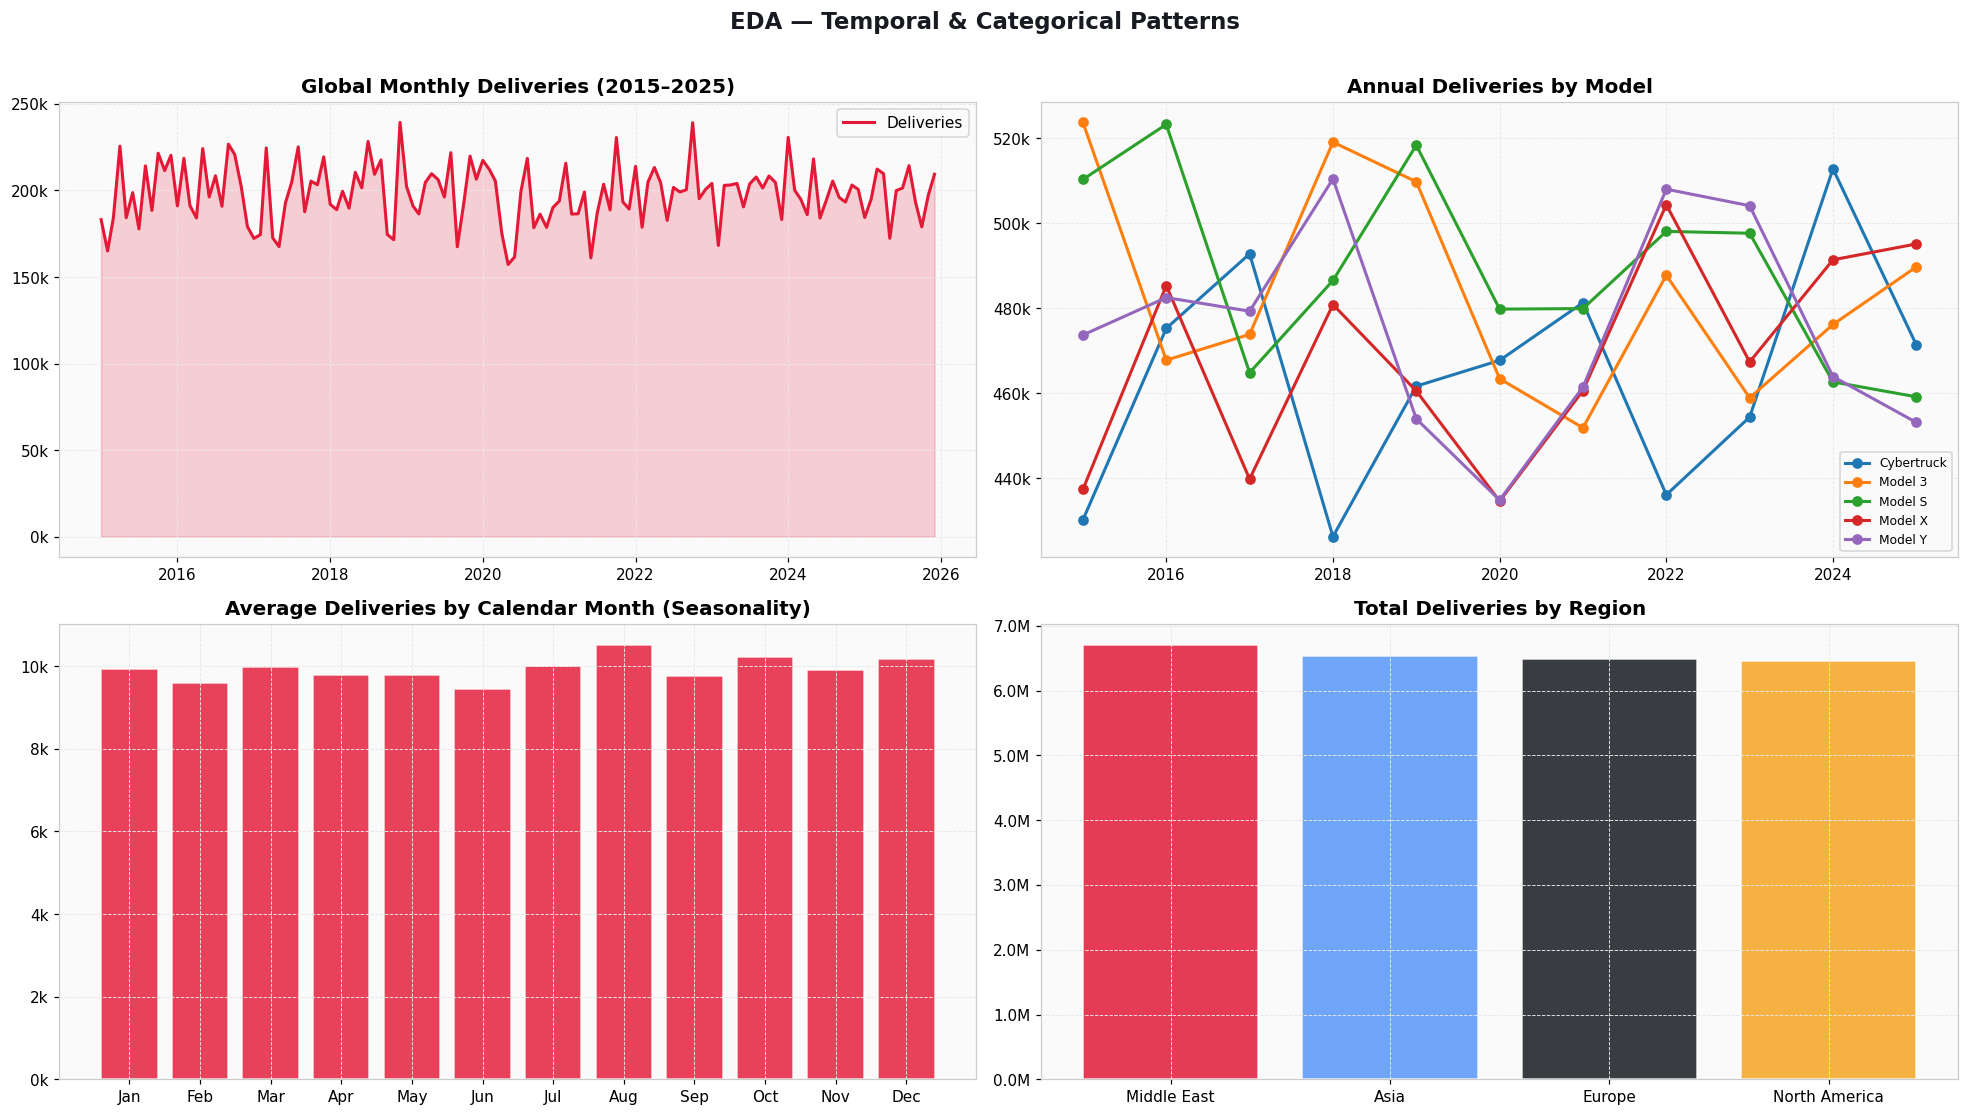

In [107]:
# ── 2.4 Target over time — trend & seasonality ───────────────
monthly = (df.groupby(["Year","Month"])
             .agg(Deliveries=("Estimated_Deliveries","sum"),
                  Production=("Production_Units","sum"))
             .reset_index())
monthly["Date"] = pd.to_datetime(
    monthly["Year"].astype(str)+"-"+monthly["Month"].astype(str).str.zfill(2))
monthly = monthly.sort_values("Date")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Global trend
axes[0,0].plot(monthly["Date"], monthly["Deliveries"],
               color=RED, lw=2, label="Deliveries")
axes[0,0].fill_between(monthly["Date"], monthly["Deliveries"],
                       alpha=0.2, color=RED)
axes[0,0].set_title("Global Monthly Deliveries (2015–2025)")
axes[0,0].yaxis.set_major_formatter(kfmt); axes[0,0].legend()

# By model
for model, grp in df.groupby("Model"):
    m_yr = grp.groupby("Year")["Estimated_Deliveries"].sum()
    axes[0,1].plot(m_yr.index, m_yr.values, marker="o", lw=2, label=model)
axes[0,1].set_title("Annual Deliveries by Model")
axes[0,1].yaxis.set_major_formatter(kfmt); axes[0,1].legend(fontsize=8)

# Seasonal bar — month average
month_avg = df.groupby("Month")["Estimated_Deliveries"].mean()
m_lbls = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1,0].bar(m_lbls, month_avg.values, color=RED, alpha=0.82, edgecolor="white")
axes[1,0].set_title("Average Deliveries by Calendar Month (Seasonality)")
axes[1,0].yaxis.set_major_formatter(kfmt)

# Region share
r_share = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)
axes[1,1].bar(r_share.index, r_share.values,
              color=[RED, BLUE, DARK, GOLD], edgecolor="white", alpha=0.85)
axes[1,1].set_title("Total Deliveries by Region")
axes[1,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

fig.suptitle("EDA — Temporal & Categorical Patterns",
             fontsize=15, fontweight="bold", color=DARK, y=1.01)
plt.tight_layout()
plt.show()


## 3 · Encoding Techniques

Categorical variables must be converted to numbers before feeding to models.

| Technique | When to use |
|---|---|
| **Label Encoding** | Ordinal data or tree-based models |
| **One-Hot Encoding** | Nominal data; linear/distance-based models |

⚠️ **Data Leakage rule**: fit the encoder on **train only**, then transform both train and test.


In [108]:
# ── 3.1 Label Encoding ────────────────────────────────────────
le_source = LabelEncoder()
# Fit on full column (no leakage issue for a fixed known set of labels)
df["Source_enc"] = le_source.fit_transform(df["Source_Type"])

print("Label Encoding — Source_Type:")
mapping = dict(zip(le_source.classes_, le_source.transform(le_source.classes_)))
for k, v in mapping.items():
    print(f"  '{k}' -> {v}")


Label Encoding — Source_Type:
  'Estimated (Region)' -> 0
  'Interpolated (Month)' -> 1
  'Official (Quarter)' -> 2


In [109]:
# ── 3.2 One-Hot Encoding ─────────────────────────────────────
# Creates a binary column for each category
ohe_demo = pd.get_dummies(df[["Region", "Model"]], prefix=["Region","Model"],
                           drop_first=False)
print(f"One-Hot Encoding produced {ohe_demo.shape[1]} columns:")
print(ohe_demo.columns.tolist())
print()
display(ohe_demo.head(4))


One-Hot Encoding produced 9 columns:
['Region_Asia', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Cybertruck', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y']



,Region_Asia,Region_Europe,Region_Middle East,Region_North America,Model_Cybertruck,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
0,False,True,False,False,False,False,True,False,False
1,True,False,False,False,False,False,False,True,False
2,False,False,False,True,False,False,False,True,False
3,False,False,False,True,False,True,False,False,False


In [110]:
# ── 3.3 Apply to full dataframe ───────────────────────────────
df_enc = df.copy()
df_enc = pd.get_dummies(df_enc, columns=["Region","Model"], drop_first=False)
df_enc = df_enc.drop(columns=["Source_Type"])   # already encoded as Source_enc

CAT_COLS = [c for c in df_enc.columns
            if df_enc[c].dtype == bool or str(df_enc[c].dtype) == "bool"]
# Convert bool dummies to int
for c in df_enc.select_dtypes(include="bool").columns:
    df_enc[c] = df_enc[c].astype(int)

print(f"Shape after encoding: {df_enc.shape}")
print("New columns added:", [c for c in df_enc.columns if c not in df.columns])


Shape after encoding: (2640, 19)
New columns added: ['Region_Asia', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Cybertruck', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y']


## 4 · Feature Scaling

Scaling ensures that features with large ranges (e.g. `Avg_Price_USD` ~ $100k) don't dominate
features with small ranges (e.g. `Month` 1–12).

| Scaler | Formula | Best when |
|---|---|---|
| **StandardScaler** | (x − μ) / σ | Data is roughly Gaussian |
| **RobustScaler** | (x − median) / IQR | Data has outliers |
| **MinMaxScaler** | (x − min) / (max − min) | Fixed bounded range needed |

We use **RobustScaler** here because the delivery data has heavy tails.


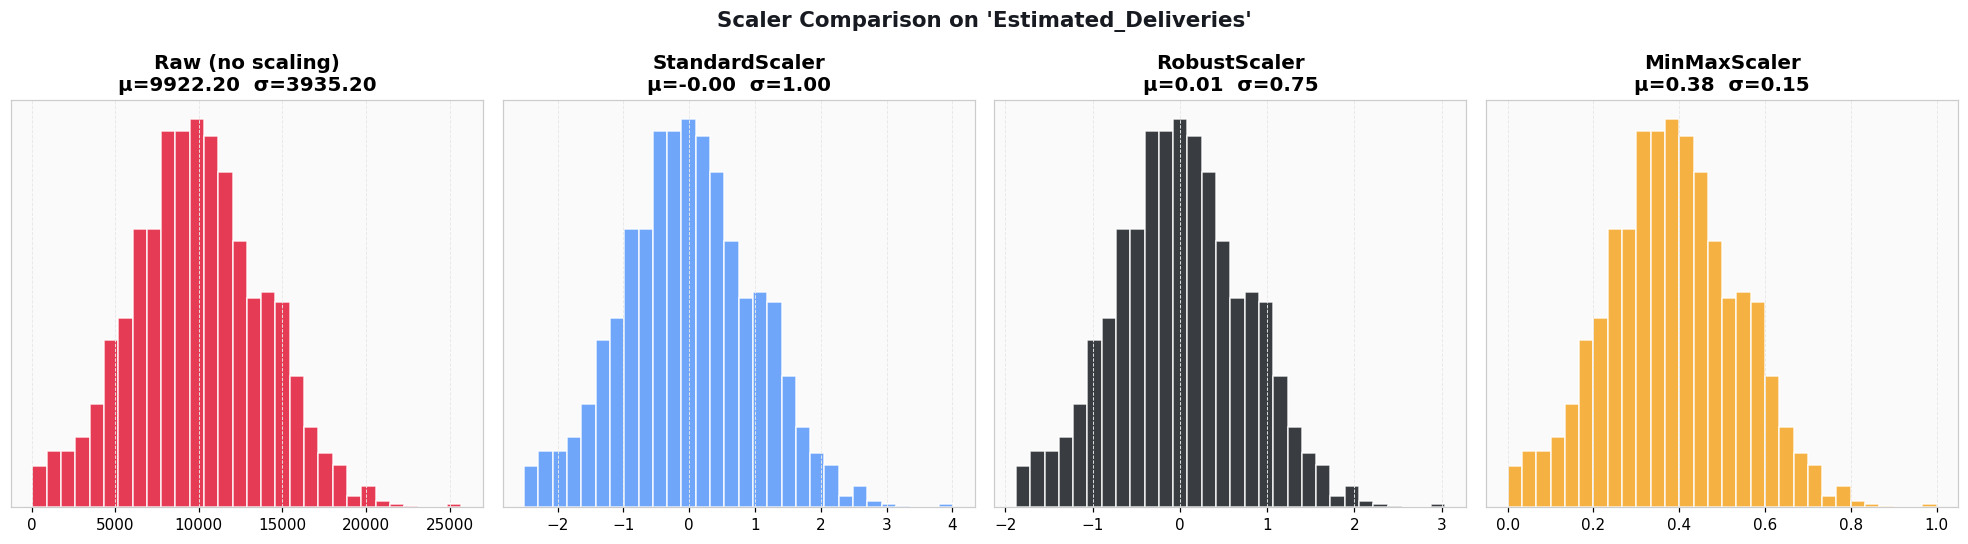

✅  We will use RobustScaler in our pipeline (robust to outliers).


In [111]:
# ── 4.1 Visual comparison of scalers ─────────────────────────
from sklearn.preprocessing import MinMaxScaler

col_demo = "Estimated_Deliveries"
raw_vals = df[[col_demo]].values

std_vals   = StandardScaler().fit_transform(raw_vals)
rob_vals   = RobustScaler().fit_transform(raw_vals)
minmax_vals = MinMaxScaler().fit_transform(raw_vals)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
configs = [
    (raw_vals,    "Raw (no scaling)",  RED),
    (std_vals,    "StandardScaler",    BLUE),
    (rob_vals,    "RobustScaler",      DARK),
    (minmax_vals, "MinMaxScaler",      GOLD),
]
for ax, (vals, title, color) in zip(axes, configs):
    ax.hist(vals.flatten(), bins=30, color=color, alpha=0.85, edgecolor="white")
    ax.set_title(f"{title}\nμ={vals.mean():.2f}  σ={vals.std():.2f}")
    ax.yaxis.set_visible(False)

fig.suptitle(f"Scaler Comparison on '{col_demo}'",
             fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
plt.show()
print("✅  We will use RobustScaler in our pipeline (robust to outliers).")


## 5 · Feature Engineering

We create new informative features from existing ones.

**Date features** — extract temporal signals  
**Cyclical encoding** — Month as sin/cos to preserve circular nature (Jan ≈ Dec)  
**Lag features** — past values as predictors (critical for time series)  
**Rolling statistics** — smoothed trend signal (moving average, std)  


In [112]:
# ── 5.1 Date features ─────────────────────────────────────────
df_fe = df_enc.copy()
df_fe["Date"]               = pd.to_datetime(
    df_fe["Year"].astype(str)+"-"+df_fe["Month"].astype(str).str.zfill(2))
df_fe["Quarter"]            = ((df_fe["Month"]-1)//3+1).astype(int)
df_fe["Is_Q4"]              = (df_fe["Quarter"]==4).astype(int)
df_fe["Is_Q3"]              = (df_fe["Quarter"]==3).astype(int)
df_fe["Years_since_launch"] = df_fe["Year"] - 2015

print("Date features added: Quarter, Is_Q4, Is_Q3, Years_since_launch")


Date features added: Quarter, Is_Q4, Is_Q3, Years_since_launch


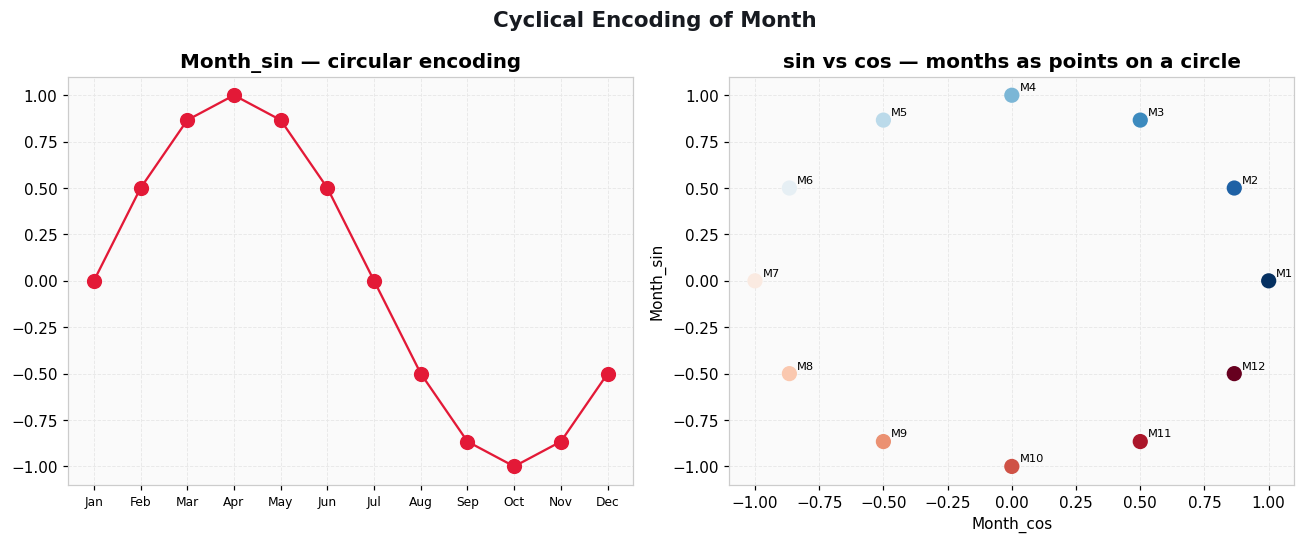

In [113]:
# ── 5.2 Cyclical encoding (Month) ────────────────────────────
# Month 1 and Month 12 are adjacent — linear encoding misses this
df_fe["Month_sin"] = np.sin(2 * np.pi * df_fe["Month"] / 12)
df_fe["Month_cos"] = np.cos(2 * np.pi * df_fe["Month"] / 12)

# Visualise cyclical encoding
theta = np.linspace(0, 2*np.pi, 13)[:-1]
m_sin = np.sin(theta)
m_cos = np.cos(theta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(range(1,13), m_sin, color=RED, s=80, zorder=5)
axes[0].plot(range(1,13), m_sin, color=RED, lw=1.5)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=8)
axes[0].set_title("Month_sin — circular encoding")

axes[1].scatter(m_cos, m_sin, s=80, c=range(1,13), cmap="RdBu_r", zorder=5)
for i in range(12):
    axes[1].annotate(f"M{i+1}", (m_cos[i], m_sin[i]), textcoords="offset points",
                      xytext=(5,3), fontsize=7.5)
axes[1].set_title("sin vs cos — months as points on a circle")
axes[1].set_xlabel("Month_cos"); axes[1].set_ylabel("Month_sin")

fig.suptitle("Cyclical Encoding of Month", fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
plt.show()


Lag features created:
   ['Del_Lag_1', 'Prod_Lag_1', 'Del_Lag_2', 'Prod_Lag_2', 'Del_Lag_3', 'Prod_Lag_3', 'Del_Lag_6', 'Prod_Lag_6', 'Del_Lag_12', 'Prod_Lag_12']


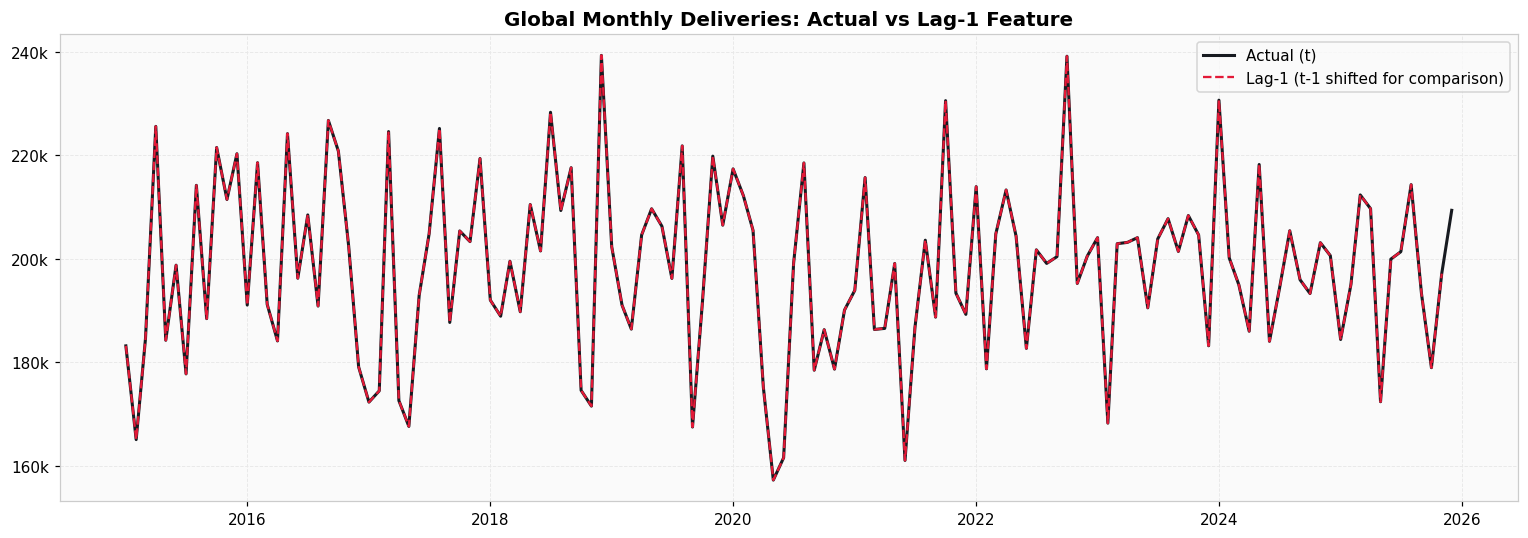

In [114]:
# ── 5.3 Lag features ──────────────────────────────────────────
# Lag features = the value of the target at previous time steps.
# They are the most powerful predictor for time series problems.

# Compute global monthly total first
monthly_total = (df_fe.groupby("Date")["Estimated_Deliveries"]
                       .sum().sort_index())
monthly_prod  = (df_fe.groupby("Date")["Production_Units"]
                       .sum().sort_index())

lag_df = pd.DataFrame({"Global_Del":  monthly_total,
                        "Global_Prod": monthly_prod})

# ── Lag features ─────────────────────────────────────────────
for lag in [1, 2, 3, 6, 12]:
    lag_df[f"Del_Lag_{lag}"]  = monthly_total.shift(lag)
    lag_df[f"Prod_Lag_{lag}"] = monthly_prod.shift(lag)

print("Lag features created:")
lag_cols = [c for c in lag_df.columns if "Lag" in c]
print("  ", lag_cols)

# Visualise lag-1 vs actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lag_df.index, lag_df["Global_Del"],
        color=DARK, lw=2, label="Actual (t)")
ax.plot(lag_df.index, lag_df["Del_Lag_1"].shift(-1),
        color=RED, lw=1.5, linestyle="--", label="Lag-1 (t-1 shifted for comparison)")
ax.set_title("Global Monthly Deliveries: Actual vs Lag-1 Feature")
ax.yaxis.set_major_formatter(kfmt); ax.legend()
plt.tight_layout()
plt.show()


Rolling features created: ['Roll_3_mean', 'Roll_3_std', 'Roll_6_mean', 'Roll_6_std', 'Roll_12_mean', 'Roll_12_std']


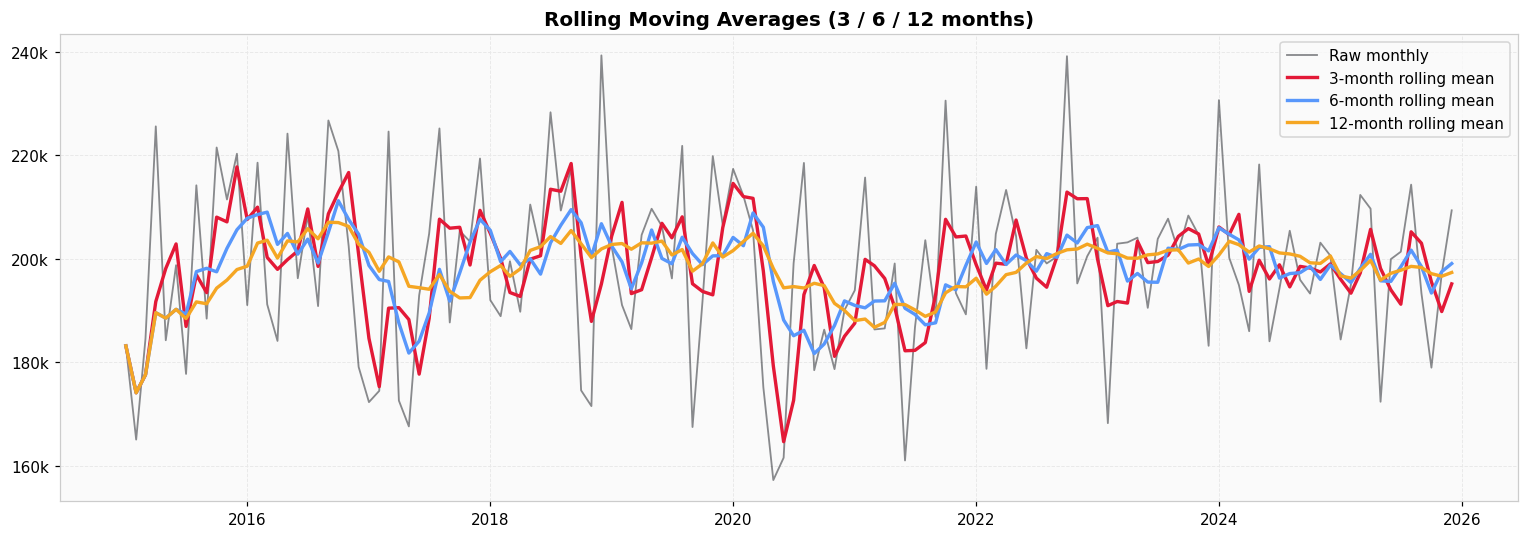

In [115]:
# ── 5.4 Rolling statistics ────────────────────────────────────
# Rolling features smooth out noise and capture the local trend.

for w in [3, 6, 12]:
    lag_df[f"Roll_{w}_mean"] = monthly_total.rolling(w, min_periods=1).mean()
    lag_df[f"Roll_{w}_std"]  = monthly_total.rolling(w, min_periods=1).std()

roll_cols = [c for c in lag_df.columns if "Roll" in c]
print("Rolling features created:", roll_cols)

# Visualise rolling means
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lag_df.index, lag_df["Global_Del"],
        color=DARK, lw=1.2, alpha=0.5, label="Raw monthly")
for w, color in zip([3, 6, 12], [RED, BLUE, GOLD]):
    ax.plot(lag_df.index, lag_df[f"Roll_{w}_mean"],
            lw=2.2, label=f"{w}-month rolling mean", color=color)
ax.set_title("Rolling Moving Averages (3 / 6 / 12 months)")
ax.yaxis.set_major_formatter(kfmt); ax.legend()
plt.tight_layout()
plt.show()


In [116]:
# ── 5.5 Ratio / interaction features ─────────────────────────
df_fe["Range_per_kWh"]   = df_fe["Range_km"] / df_fe["Battery_Capacity_kWh"]
df_fe["Prod_Del_Ratio"]  = (df_fe["Production_Units"] /
                            df_fe["Estimated_Deliveries"].replace(0, np.nan))

# ── 5.6 Merge lag_df back ─────────────────────────────────────
lag_df_reset = lag_df.reset_index()
df_fe = df_fe.merge(lag_df_reset, on="Date", how="left")

# ── Drop leakage & helper columns (see Section 6) ─────────────
DROP_LATER = ["Date","Source_enc","Global_Del","Global_Prod"]
df_fe = df_fe.drop(columns=DROP_LATER, errors="ignore")
df_fe = df_fe.fillna(df_fe.median(numeric_only=True))

print(f"Final feature matrix: {df_fe.shape[0]:,} rows × {df_fe.shape[1]} columns")
new_feats = [c for c in df_fe.columns
             if c not in df_raw.columns and c != "Source_enc"]
print(f"\nEngineered features ({len(new_feats)}):")
print(new_feats)


Final feature matrix: 2,640 rows × 42 columns

Engineered features (33):
['Region_Asia', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Cybertruck', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Quarter', 'Is_Q4', 'Is_Q3', 'Years_since_launch', 'Month_sin', 'Month_cos', 'Range_per_kWh', 'Prod_Del_Ratio', 'Del_Lag_1', 'Prod_Lag_1', 'Del_Lag_2', 'Prod_Lag_2', 'Del_Lag_3', 'Prod_Lag_3', 'Del_Lag_6', 'Prod_Lag_6', 'Del_Lag_12', 'Prod_Lag_12', 'Roll_3_mean', 'Roll_3_std', 'Roll_6_mean', 'Roll_6_std', 'Roll_12_mean', 'Roll_12_std']


## 6 · Data Leakage

**Data leakage** occurs when information from the **test set** or **future** leaks into
the training process — producing overly optimistic metrics that fail in production.

### Common types:
| Type | Example | Fix |
|---|---|---|
| **Target leakage** | Using `Revenue` (= Deliveries × Price) to predict Deliveries | Drop all features derived from target |
| **Temporal leakage** | Using tomorrow's sales to predict today | Chronological split, lag correctly |
| **Preprocessing leakage** | Scaling/encoding entire dataset before splitting | Fit transformers only on train set |


In [117]:
# ── 6.1 Demonstrate leakage risk ─────────────────────────────
# If we included Revenue_est = Deliveries × Price as a feature,
# it would perfectly predict Deliveries — but only because it IS Deliveries.

df_fe["Revenue_LEAKY"] = df_fe["Estimated_Deliveries"] * df_fe["Avg_Price_USD"]

# Quick demonstration: correlation
leaky_corr = df_fe["Revenue_LEAKY"].corr(df_fe["Estimated_Deliveries"])
print(f"Correlation of Revenue_LEAKY with target: {leaky_corr:.4f}  <-- Near-perfect = LEAKAGE!")
print("-->  Dropping Revenue_LEAKY from feature set.")
df_fe.drop(columns=["Revenue_LEAKY"], inplace=True)

# ── 6.2 Leakage-safe rule: lag correctly ─────────────────────
print(
    "[OK]  Use Del_Lag_1 (yesterday deliveries to predict today)"
    "[BAD] Use Del_Lag_0 (today deliveries to predict today -- same thing!)"
    "[OK]  Fit StandardScaler only on X_train, then transform X_test"
    "[BAD] Fit StandardScaler on full X before splitting"
)


Correlation of Revenue_LEAKY with target: 0.8415  <-- Near-perfect = LEAKAGE!
-->  Dropping Revenue_LEAKY from feature set.
[OK]  Use Del_Lag_1 (yesterday deliveries to predict today)[BAD] Use Del_Lag_0 (today deliveries to predict today -- same thing!)[OK]  Fit StandardScaler only on X_train, then transform X_test[BAD] Fit StandardScaler on full X before splitting


## 7 · Sklearn Pipelines

A `Pipeline` chains preprocessing and modelling steps into a **single object**.

**Benefits:**
- Prevents preprocessing leakage (transformers fit only on train data)
- Cleaner code — one `.fit()` and `.predict()`
- Works natively with `cross_val_score` and `GridSearchCV`


In [118]:
# ── 7.1 Build a leakage-safe pipeline ────────────────────────
TARGET    = "Estimated_Deliveries"
feat_cols = [c for c in df_fe.columns if c != TARGET]

df_sorted = df_fe.sort_values(["Year","Month"]).reset_index(drop=True)
X_all = df_sorted[feat_cols].values
y_all = df_sorted[TARGET].values

SPLIT       = int(len(X_all) * 0.80)
X_train_raw = X_all[:SPLIT]
X_test_raw  = X_all[SPLIT:]
y_train     = y_all[:SPLIT]
y_test      = y_all[SPLIT:]

# Pipeline: RobustScaler -> LinearRegression
pipe_lr = Pipeline([
    ("scaler", RobustScaler()),
    ("model",  LinearRegression()),
])

pipe_lr.fit(X_train_raw, y_train)
pred_lr_pipe = pipe_lr.predict(X_test_raw)
r2_pipe = r2_score(y_test, pred_lr_pipe)
print("Pipeline steps:")
for step_name, step_obj in pipe_lr.steps:
    print(f"  [{step_name}]  ->  {step_obj}")
print(f"\nLinear Regression (via Pipeline) R² on test: {r2_pipe:.4f}")
print("\n✅ Scaler was fitted only on X_train_raw — no leakage!")


Pipeline steps:
  [scaler]  ->  RobustScaler()
  [model]  ->  LinearRegression()

Linear Regression (via Pipeline) R² on test: 0.9983

✅ Scaler was fitted only on X_train_raw — no leakage!


## 8 · Chronological Split

For time series data, **random splitting is wrong** because:
- It lets the model "see the future" during training
- Destroys temporal autocorrelation patterns

✅ Always split so that **all training data comes before all test data**.


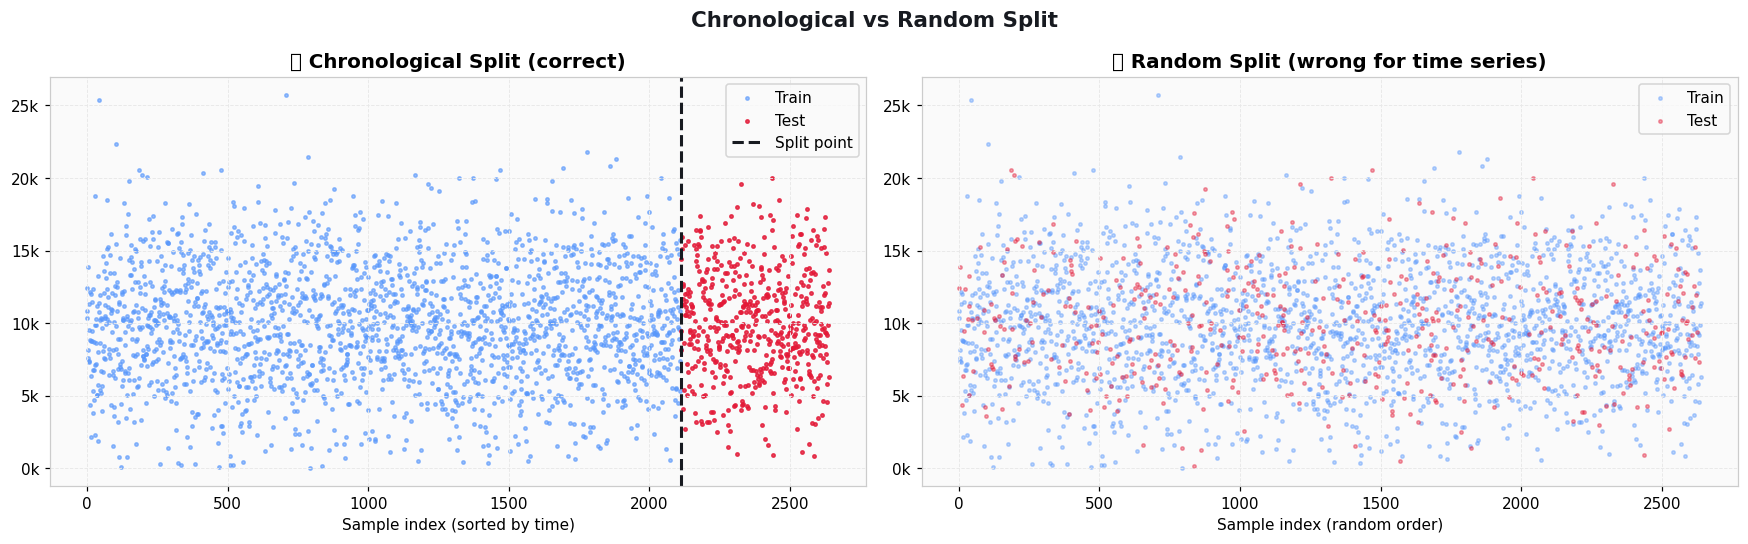

Train size: 2,112  (80%)
Test  size: 528  (20%)

✅ RobustScaler fitted on X_train only — applied to X_test.


In [119]:
# ── 8.1 Visualise chronological vs random split ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

time_idx = np.arange(len(y_all))

# Chronological split
axes[0].scatter(time_idx[:SPLIT],  y_all[:SPLIT],
                color=BLUE, s=5, alpha=0.6, label="Train")
axes[0].scatter(time_idx[SPLIT:], y_all[SPLIT:],
                color=RED, s=5, alpha=0.8, label="Test")
axes[0].axvline(SPLIT, color=DARK, lw=2, linestyle="--", label="Split point")
axes[0].set_title("✅ Chronological Split (correct)")
axes[0].set_xlabel("Sample index (sorted by time)")
axes[0].yaxis.set_major_formatter(kfmt); axes[0].legend()

# Random split (wrong for TS)
rnd_idx = np.random.permutation(len(y_all))
r_train, r_test = rnd_idx[:SPLIT], rnd_idx[SPLIT:]
axes[1].scatter(r_train, y_all[r_train],
                color=BLUE, s=5, alpha=0.4, label="Train")
axes[1].scatter(r_test,  y_all[r_test],
                color=RED, s=5, alpha=0.4, label="Test")
axes[1].set_title("❌ Random Split (wrong for time series)")
axes[1].set_xlabel("Sample index (random order)")
axes[1].yaxis.set_major_formatter(kfmt); axes[1].legend()

fig.suptitle("Chronological vs Random Split", fontsize=14,
             fontweight="bold", color=DARK)
plt.tight_layout()
plt.show()

print(f"Train size: {SPLIT:,}  ({100*SPLIT/len(X_all):.0f}%)")
print(f"Test  size: {len(X_all)-SPLIT:,}  ({100*(len(X_all)-SPLIT)/len(X_all):.0f}%)")

# Apply scaler — fitted on train ONLY
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
print("\n✅ RobustScaler fitted on X_train only — applied to X_test.")


## 9 · Regression Models

We train three linear models and compare them:

| Model | Penalty | Effect |
|---|---|---|
| **Linear Regression** | None (OLS) | Best fit to training data, may overfit |
| **Ridge (L2)** | λ · Σ βᵢ² | Shrinks all coefficients — good with multicollinearity |
| **Lasso (L1)** | λ · Σ |βᵢ| | Forces some coefficients to exactly 0 — built-in feature selection |


In [120]:
# ── 9.1 Fit three models ──────────────────────────────────────
models = {
    "Linear Regression": LinearRegression(),
    "Ridge  (L2, α=10)": Ridge(alpha=10.0),
    "Lasso  (L1, α=0.1)": Lasso(alpha=0.1, max_iter=10000),
}

predictions = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    predictions[name] = m.predict(X_test)

print("All three models fitted. ✅")


All three models fitted. ✅


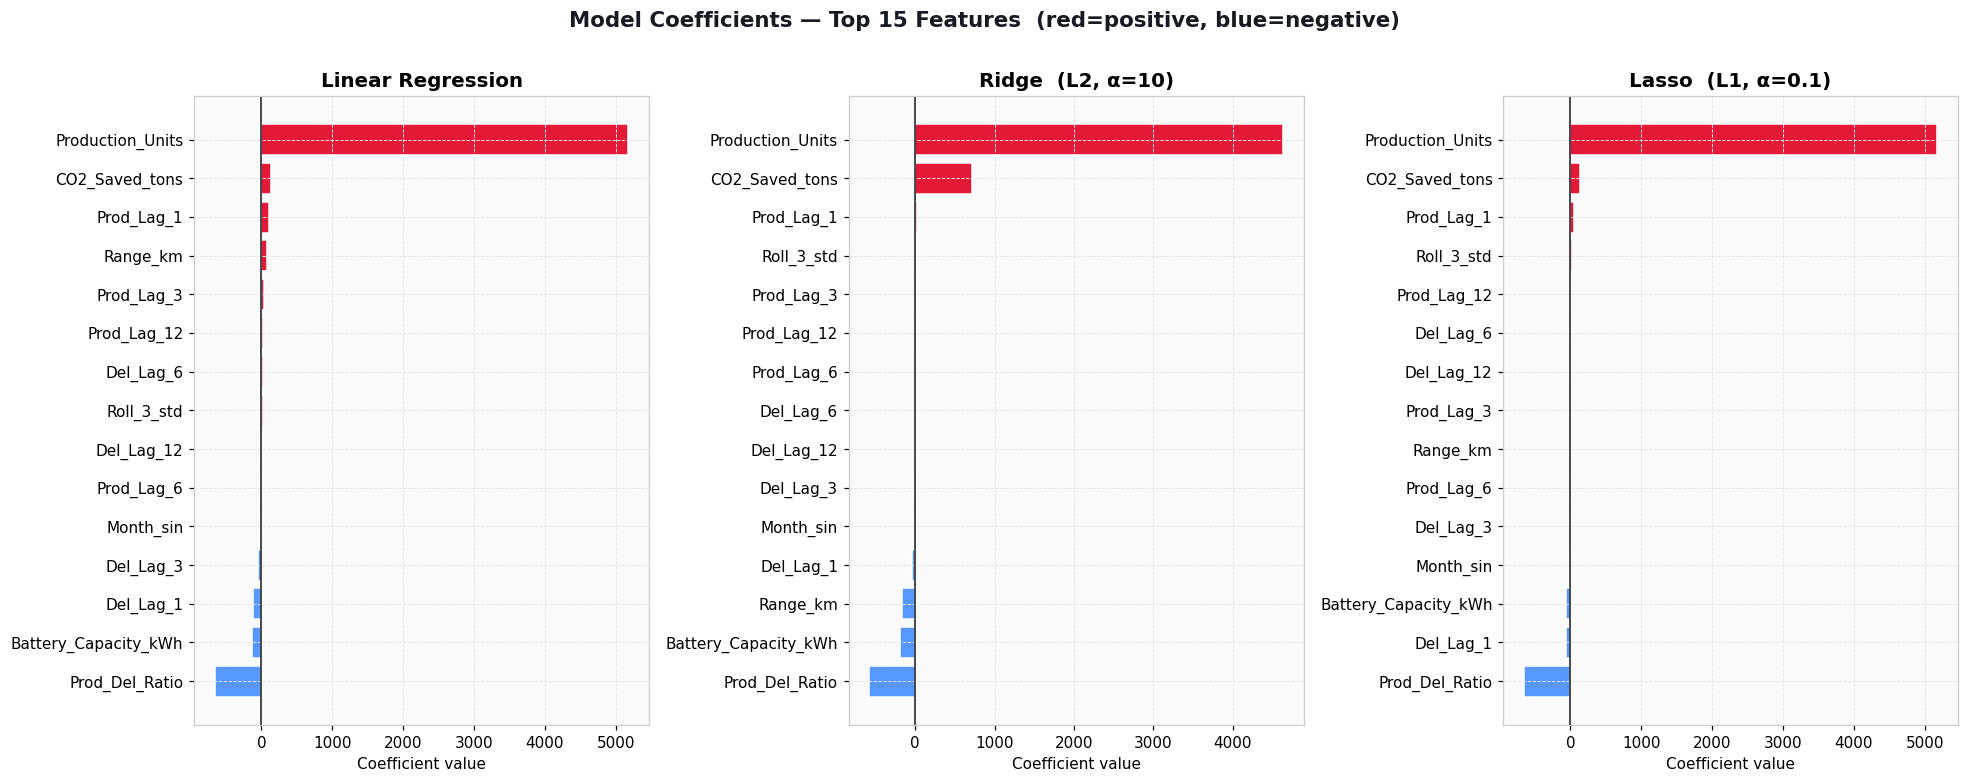


Lasso zeroed out 10/41 coefficients -> automatic feature selection!


In [121]:
# ── 9.2 Coefficient comparison ────────────────────────────────
coef_df = pd.DataFrame(
    {name: m.coef_ for name, m in models.items()},
    index=feat_cols,
)

# Show top 15 by absolute magnitude (Linear Regression)
top15 = coef_df["Linear Regression"].abs().sort_values(ascending=False).head(15).index

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
colors_map = {"Linear Regression": RED,
              "Ridge  (L2, α=10)": BLUE,
              "Lasso  (L1, α=0.1)": DARK}

for ax, (name, m) in zip(axes, models.items()):
    coefs = pd.Series(m.coef_, index=feat_cols).loc[top15].sort_values()
    bar_colors = [RED if v > 0 else BLUE for v in coefs.values]
    ax.barh(coefs.index, coefs.values, color=bar_colors, edgecolor="white")
    ax.axvline(0, color=DARK, lw=1)
    ax.set_title(name)
    ax.set_xlabel("Coefficient value")

fig.suptitle("Model Coefficients — Top 15 Features  (red=positive, blue=negative)",
             fontsize=14, fontweight="bold", color=DARK, y=1.01)
plt.tight_layout()
plt.show()

# Count Lasso zeroed coefficients
n_zero = (models["Lasso  (L1, α=0.1)"].coef_ == 0).sum()
print(f"\nLasso zeroed out {n_zero}/{len(feat_cols)} coefficients -> automatic feature selection!")


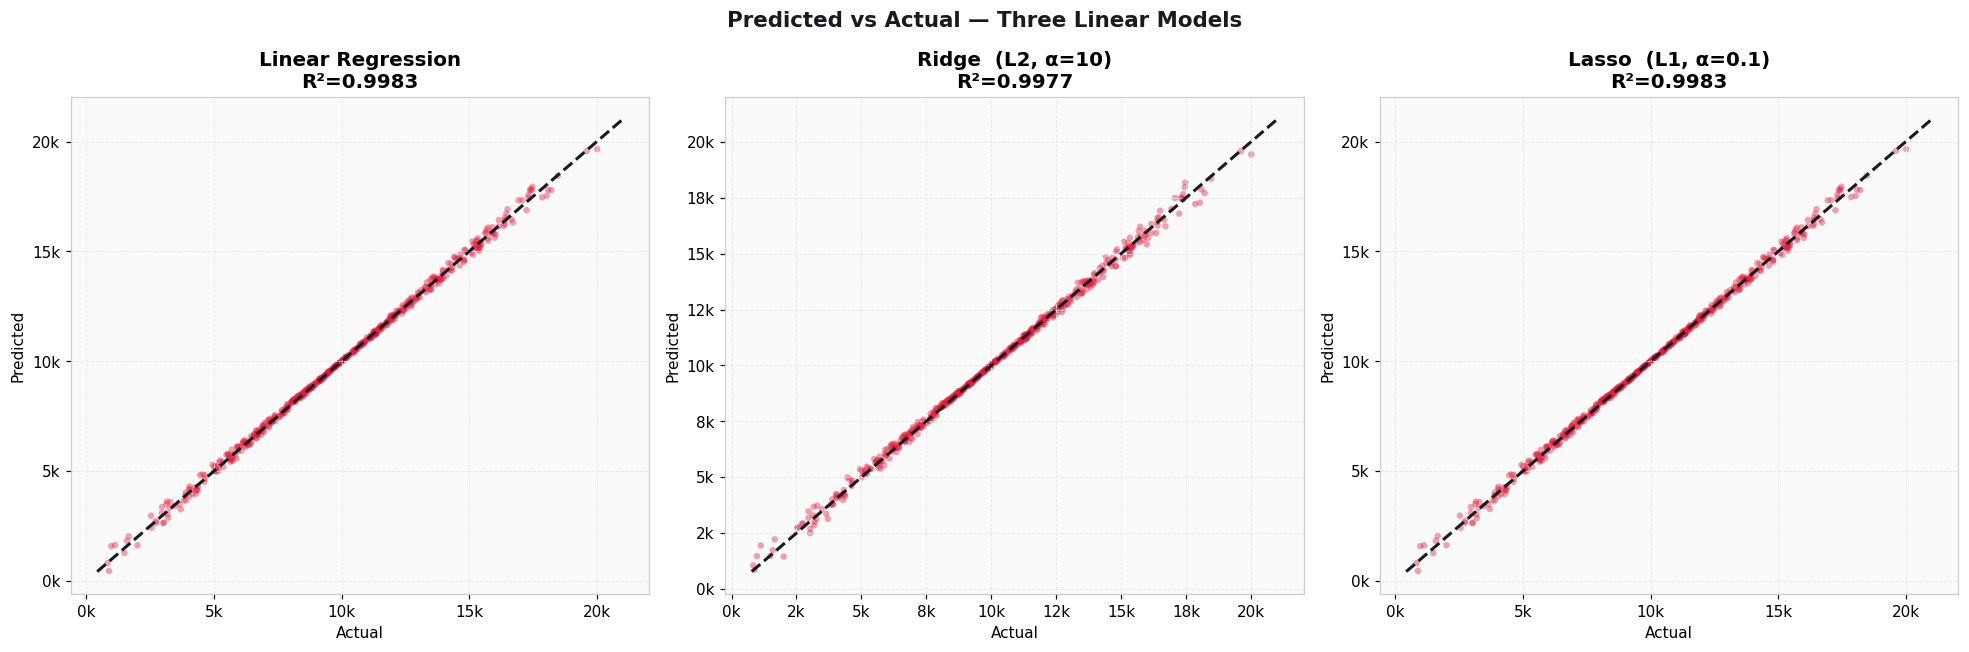

In [122]:
# ── 9.3 Predictions visualised ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, pred) in zip(axes, predictions.items()):
    lim = (min(y_test.min(), pred.min())*0.93,
           max(y_test.max(), pred.max())*1.05)
    ax.scatter(y_test, pred, alpha=0.4, s=18, color=RED, edgecolors="none")
    ax.plot(lim, lim, "--", color=DARK, lw=2)
    r2  = r2_score(y_test, pred)
    ax.set_title(f"{name}\nR²={r2:.4f}")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.xaxis.set_major_formatter(kfmt)
    ax.yaxis.set_major_formatter(kfmt)

fig.suptitle("Predicted vs Actual — Three Linear Models",
             fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
plt.show()


## 10 · Bias-Variance Tradeoff & Overfitting/Underfitting

**Bias** = error from wrong assumptions (model too simple -> underfitting)  
**Variance** = error from sensitivity to training noise (model too complex -> overfitting)

**Learning curves** show how train/test error changes with training set size:
- If both curves are high -> **underfitting (high bias)**
- If train error is low but test error is high -> **overfitting (high variance)**
- If both curves converge low -> **good fit**


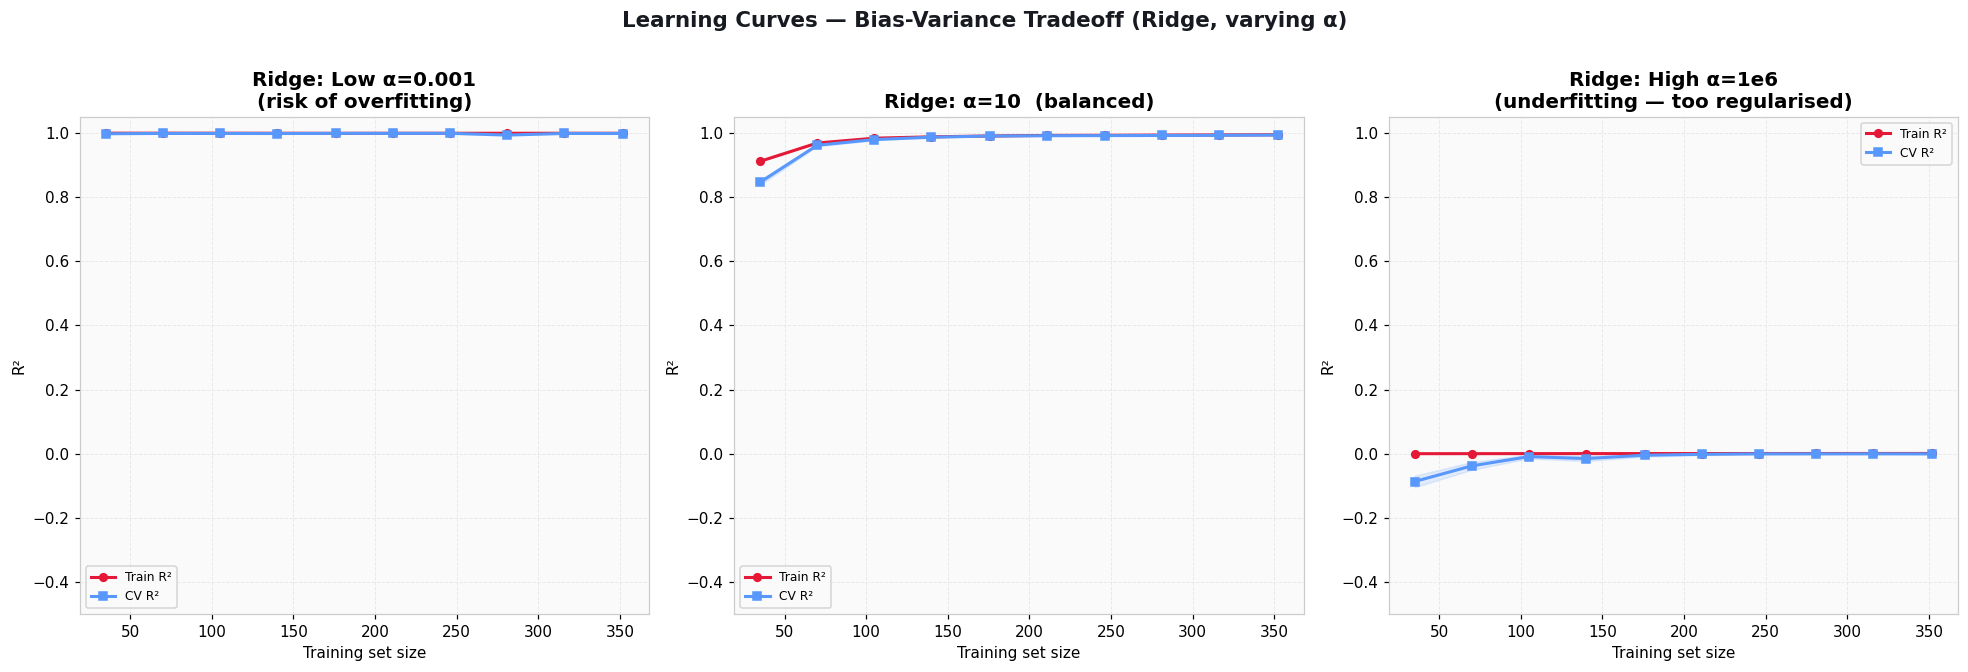

In [123]:
# ── 10.1 Learning curves for Ridge ───────────────────────────
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
alphas_demo = [0.001, 10.0, 1e6]   # underfit · balanced · overfit
titles       = ["Low α=0.001\n(risk of overfitting)",
                 "α=10  (balanced)",
                 "High α=1e6\n(underfitting — too regularised)"]

for ax, alpha, title in zip(axes, alphas_demo, titles):
    model_demo = Ridge(alpha=alpha)
    sizes, tr_scores, cv_scores = learning_curve(
        model_demo, X_train, y_train,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1)

    ax.plot(sizes, tr_scores.mean(axis=1), color=RED, lw=2,
            marker="o", markersize=5, label="Train R²")
    ax.plot(sizes, cv_scores.mean(axis=1), color=BLUE, lw=2,
            marker="s", markersize=5, label="CV R²")
    ax.fill_between(sizes,
                    tr_scores.mean(1)-tr_scores.std(1),
                    tr_scores.mean(1)+tr_scores.std(1),
                    alpha=0.15, color=RED)
    ax.fill_between(sizes,
                    cv_scores.mean(1)-cv_scores.std(1),
                    cv_scores.mean(1)+cv_scores.std(1),
                    alpha=0.15, color=BLUE)
    ax.set_title(f"Ridge: {title}")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("R²"); ax.legend(fontsize=8)
    ax.set_ylim(-0.5, 1.05)

fig.suptitle("Learning Curves — Bias-Variance Tradeoff (Ridge, varying α)",
             fontsize=14, fontweight="bold", color=DARK, y=1.01)
plt.tight_layout()
plt.show()


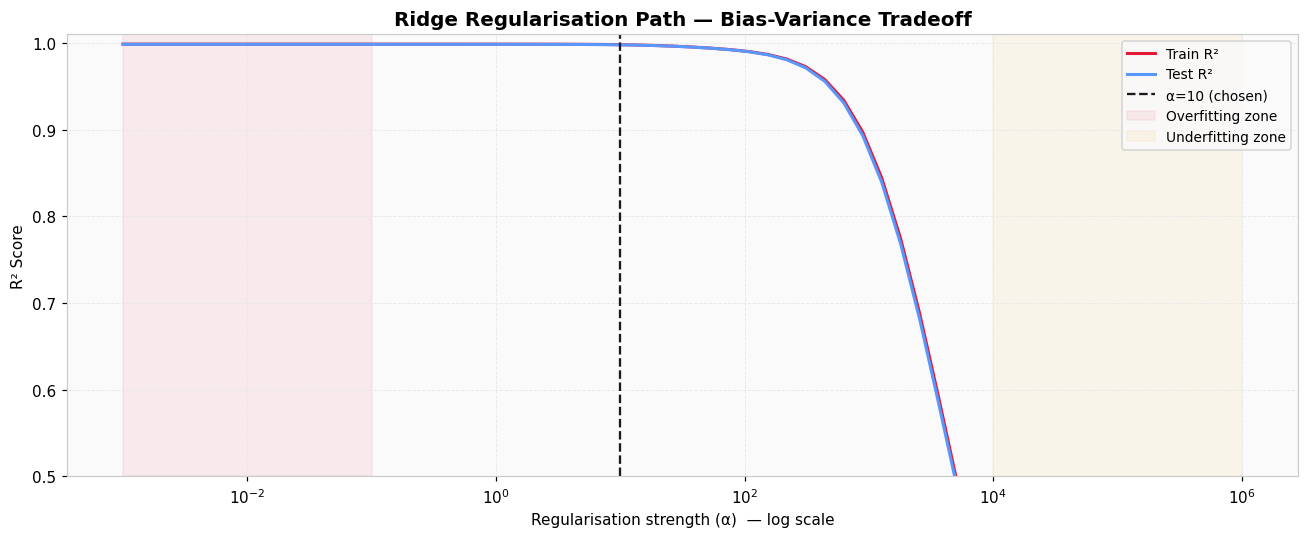

In [124]:
# ── 10.2 Regularisation path ─────────────────────────────────
# How test R² changes as we increase Ridge alpha (regularisation strength)
alphas = np.logspace(-3, 6, 60)
r2_train_list, r2_test_list = [], []

for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_train, y_train)
    r2_train_list.append(r2_score(y_train, m.predict(X_train)))
    r2_test_list.append(r2_score(y_test,  m.predict(X_test)))

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogx(alphas, r2_train_list, color=RED,  lw=2, label="Train R²")
ax.semilogx(alphas, r2_test_list,  color=BLUE, lw=2, label="Test R²")
ax.axvline(10, color=DARK, lw=1.5, linestyle="--", label="α=10 (chosen)")

# Annotate zones
ax.axvspan(alphas[0], 0.1,   alpha=0.07, color=RED,  label="Overfitting zone")
ax.axvspan(1e4, alphas[-1],  alpha=0.07, color=GOLD, label="Underfitting zone")

ax.set_xlabel("Regularisation strength (α)  — log scale")
ax.set_ylabel("R² Score")
ax.set_title("Ridge Regularisation Path — Bias-Variance Tradeoff")
ax.legend(fontsize=9); ax.set_ylim(0.5, 1.01)
plt.tight_layout()
plt.show()


## 11 · Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **RMSE** | √(Σ(y−ŷ)²/n) | Same units as target; penalises large errors |
| **MAE** | Σ|y−ŷ|/n | Robust to outliers; interpretable |
| **MAPE** | Σ|y−ŷ|/y × 100% | Scale-free; % error |
| **R²** | 1 − SS_res/SS_tot | % variance explained; 1.0 = perfect |


In [125]:
# ── 11.1 Full metrics table ───────────────────────────────────
def metrics(name, true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    mape = mean_absolute_percentage_error(true, pred)*100
    r2   = r2_score(true, pred)
    return {"Model":name,"RMSE":rmse,"MAE":mae,"MAPE%":mape,"R²":r2}

rows = [metrics(n, y_test, p) for n, p in predictions.items()]
eval_df = pd.DataFrame(rows).sort_values("R²", ascending=False)

display(eval_df.style
        .highlight_max(subset=["R²"], color="#d4efdf")
        .highlight_min(subset=["RMSE","MAE","MAPE%"], color="#d4efdf")
        .format({"RMSE":"{:,.0f}","MAE":"{:,.0f}",
                 "MAPE%":"{:.2f}%","R²":"{:.4f}"}))


,Model,RMSE,MAE,MAPE%,R²
2,"Lasso (L1, α=0.1)",151,106,1.70%,0.9983
0,Linear Regression,151,107,1.71%,0.9983
1,"Ridge (L2, α=10)",176,119,1.83%,0.9977


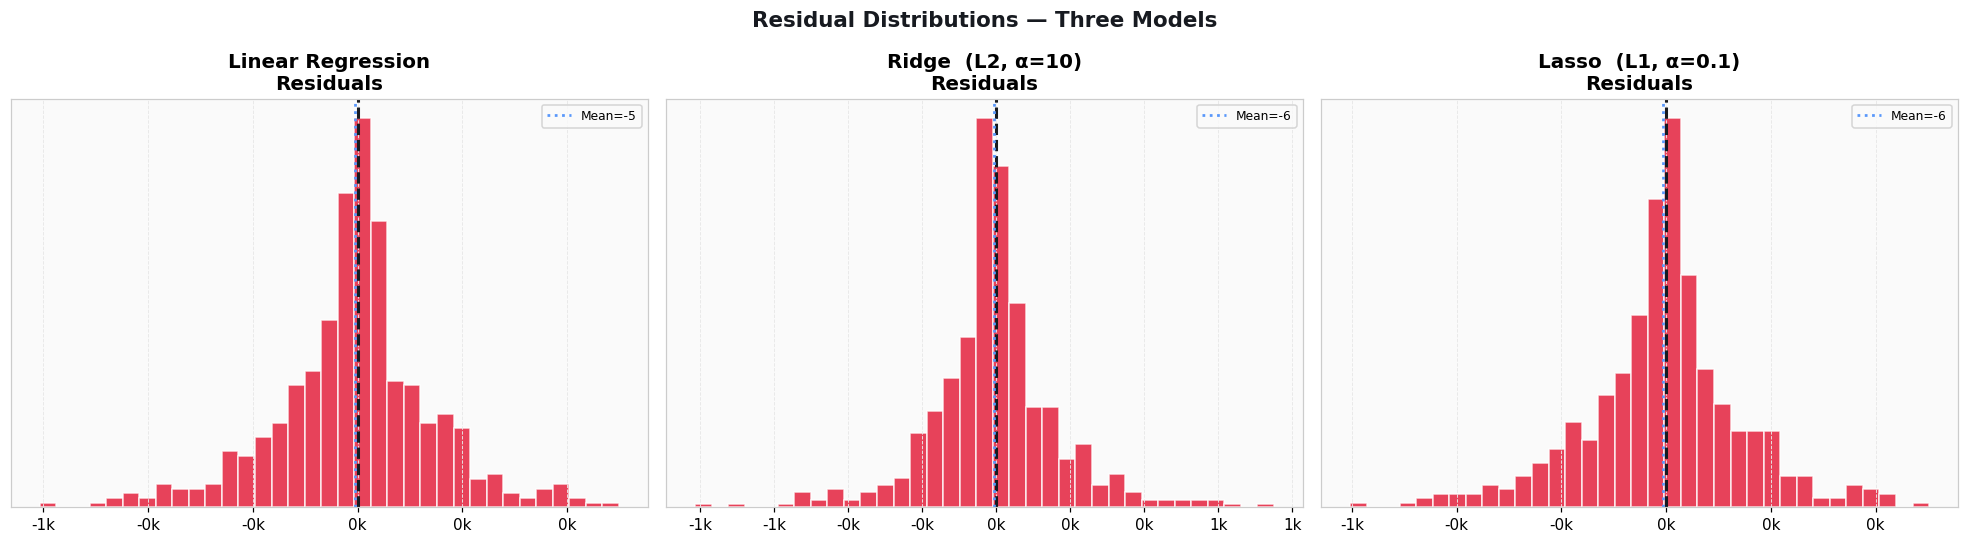

In [126]:
# ── 11.2 Residual analysis ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, predictions.items()):
    resid = y_test - pred
    ax.hist(resid, bins=35, color=RED, alpha=0.82, edgecolor="white")
    ax.axvline(0,             color=DARK, lw=2, linestyle="--")
    ax.axvline(resid.mean(),  color=BLUE, lw=1.8, linestyle=":",
               label=f"Mean={resid.mean():,.0f}")
    ax.set_title(f"{name}\nResiduals")
    ax.xaxis.set_major_formatter(kfmt)
    ax.yaxis.set_visible(False); ax.legend(fontsize=8)

fig.suptitle("Residual Distributions — Three Models",
             fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
plt.show()


## 12 · Cross Validation

Standard k-fold CV shuffles data randomly — **wrong for time series**.  
**TimeSeriesSplit** always trains on past, validates on future:

```
Fold 1:  [====Train====] [=Val=]
Fold 2:  [=====Train=====] [=Val=]
Fold 3:  [======Train======] [=Val=]
```
This prevents future leakage and gives realistic estimates.


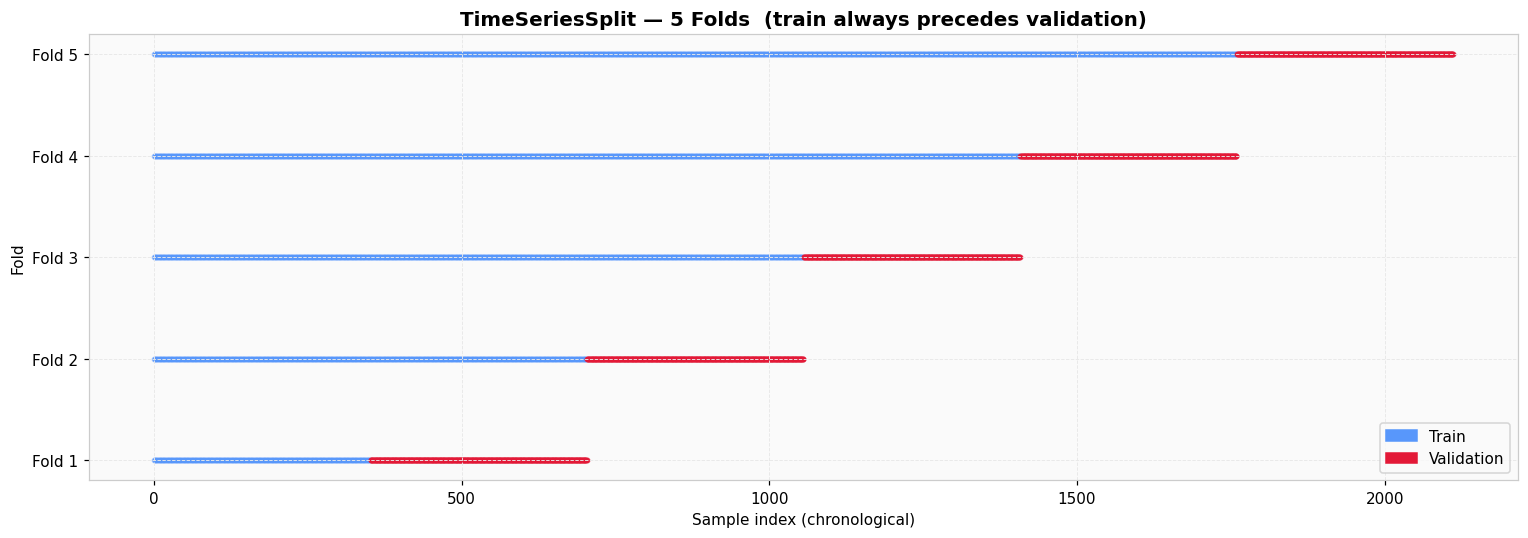

In [127]:
# ── 12.1 Visualise TimeSeriesSplit folds ─────────────────────
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(14, 5))
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    ax.scatter(tr_idx,  [fold]*len(tr_idx),
               color=BLUE, s=8, alpha=0.4)
    ax.scatter(val_idx, [fold]*len(val_idx),
               color=RED,  s=8, alpha=0.8)

# Legend proxies
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color=BLUE, label="Train"),
    mpatches.Patch(color=RED,  label="Validation")
], fontsize=10)
ax.set_xlabel("Sample index (chronological)")
ax.set_ylabel("Fold")
ax.set_title("TimeSeriesSplit — 5 Folds  (train always precedes validation)")
ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
plt.tight_layout()
plt.show()


In [128]:
# ── 12.2 CV scores for all three models ──────────────────────
print(f"{'Model':<25} {'CV R² (mean)':>14} {'CV R² (std)':>14}")
print("-"*55)
for name, m in models.items():
    cv_scores = cross_val_score(m, X_train, y_train,
                                 cv=tscv, scoring="r2")
    print(f"{name:<25} {cv_scores.mean():>14.4f} {cv_scores.std():>14.4f}")


Model                       CV R² (mean)    CV R² (std)
-------------------------------------------------------
Linear Regression                 0.9983         0.0002
Ridge  (L2, α=10)                 0.9960         0.0016
Lasso  (L1, α=0.1)                0.9984         0.0002


## 13 · Hyperparameter Tuning

Hyperparameters (e.g. `alpha` in Ridge) are not learned from data — we must search for them.

| Method | Strategy | Speed |
|---|---|---|
| **GridSearchCV** | Exhaustive — tries every combination | Slow but thorough |
| **RandomizedSearchCV** | Samples n_iter random combinations | Fast; good for large grids |

We use **TimeSeriesSplit** inside the search to avoid leakage.


In [129]:
# ── 13.1 GridSearchCV — Ridge ─────────────────────────────────
from scipy.stats import loguniform

ridge_grid = {
    "alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
}

gs_ridge = GridSearchCV(
    Ridge(), ridge_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="r2",
    n_jobs=-1,
    verbose=0,
)
gs_ridge.fit(X_train, y_train)
print(f"GridSearchCV Ridge — best α : {gs_ridge.best_params_['alpha']}")
print(f"  Best CV R²                : {gs_ridge.best_score_:.4f}")

# Show the full search results
cv_results = pd.DataFrame(gs_ridge.cv_results_)[
    ["param_alpha","mean_test_score","std_test_score","rank_test_score"]
].sort_values("rank_test_score")
display(cv_results.rename(columns={"param_alpha":"alpha",
                                    "mean_test_score":"CV R²",
                                    "std_test_score": "±",
                                    "rank_test_score":"Rank"}).reset_index(drop=True))


GridSearchCV Ridge — best α : 0.1
  Best CV R²                : 0.9983


,alpha,CV R²,±,Rank
0,0.10,0.998349,0.000212,1
1,0.01,0.998339,0.000219,2
2,1.00,0.998256,0.000311,3
3,5.00,0.997277,0.001079,4
4,10.00,0.996043,0.001635,5
5,50.00,0.987194,0.006154,6
6,100.00,0.973532,0.017485,7
7,500.00,0.836978,0.103530,8
8,1000.00,0.700701,0.141586,9


In [130]:
# ── 13.2 RandomizedSearchCV — Lasso ──────────────────────────
from scipy.stats import loguniform

lasso_dist = {"alpha": loguniform(1e-1, 50)}   # shift range higher to avoid tiny alpha

rs_lasso = RandomizedSearchCV(
    Lasso(
        max_iter=50000,        # was 10000 — give it enough iterations
        tol=1e-3,              # slightly relaxed tolerance is fine for this data
        warm_start=False,
    ),
    lasso_dist,
    n_iter=30,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
rs_lasso.fit(X_train, y_train)
print(f"Best alpha: {rs_lasso.best_params_['alpha']:.4f}")
print(f"Best CV R²: {rs_lasso.best_score_:.4f}")

Best alpha: 4.4810
Best CV R²: 0.9985



Model                        Test R²       RMSE      MAPE%
---------------------------------------------------------
Ridge (tuned)                 0.9983        151       1.70%
Lasso (tuned)                 0.9983        152       1.70%


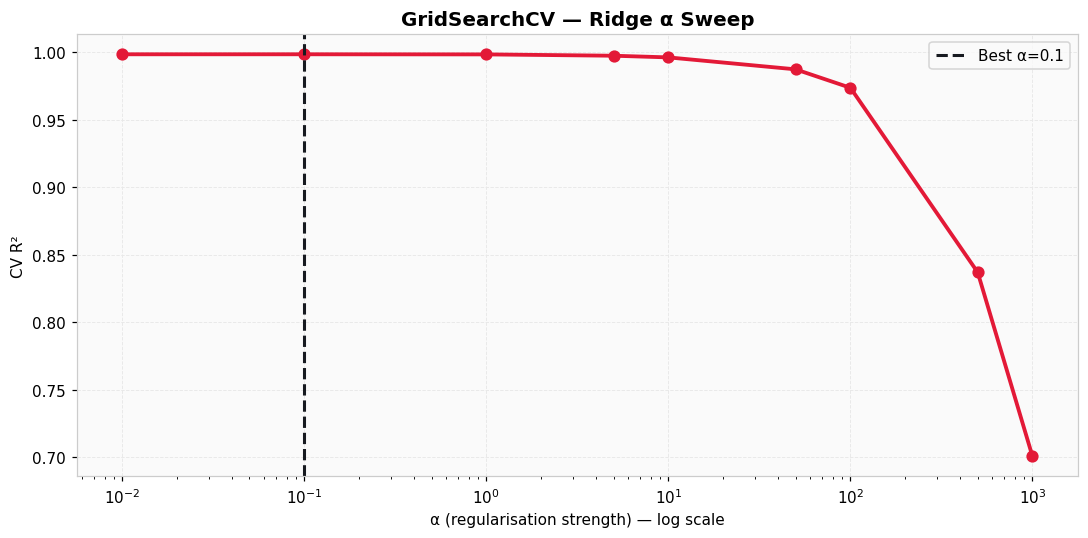

In [131]:
# ── 13.3 Evaluate tuned models ────────────────────────────────
tuned_models = {
    "Ridge (tuned)": gs_ridge.best_estimator_,
    "Lasso (tuned)": rs_lasso.best_estimator_,
}

print(f"\n{'Model':<25} {'Test R²':>10} {'RMSE':>10} {'MAPE%':>10}")
print("-"*57)
for name, m in tuned_models.items():
    pred = m.predict(X_test)
    r2   = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred)*100
    print(f"{name:<25} {r2:>10.4f} {rmse:>10,.0f} {mape:>10.2f}%")

# Compare alpha sweep
fig, ax = plt.subplots(figsize=(10, 5))
alphas_sweep = ridge_grid["alpha"]
cv_means = gs_ridge.cv_results_["mean_test_score"]
ax.semilogx(alphas_sweep, cv_means, color=RED, lw=2.5,
             marker="o", markersize=7)
ax.axvline(gs_ridge.best_params_["alpha"], color=DARK,
            lw=2, linestyle="--",
            label=f"Best α={gs_ridge.best_params_['alpha']}")
ax.set_xlabel("α (regularisation strength) — log scale")
ax.set_ylabel("CV R²")
ax.set_title("GridSearchCV — Ridge α Sweep")
ax.legend(); plt.tight_layout(); plt.show()


## 14 · Time Series Components

Any time series can be decomposed into three components:

- **Trend** — long-term direction (up/down/flat)
- **Seasonality** — repeating periodic patterns (monthly, quarterly, annual)
- **Residuals** — random noise after removing trend & seasonality

We use **multiplicative decomposition** because the seasonal amplitude grows with the trend.


In [132]:
# ── 14.1 Build clean global monthly series ────────────────────
ts = (df.groupby(["Year","Month"])["Estimated_Deliveries"]
        .sum()
        .reset_index())
ts["Date"] = pd.to_datetime(
    ts["Year"].astype(str)+"-"+ts["Month"].astype(str).str.zfill(2))
ts = ts.sort_values("Date").set_index("Date")["Estimated_Deliveries"].asfreq("MS")

print(f"Time series: {ts.index[0].date()} -> {ts.index[-1].date()}")
print(f"Length: {len(ts)} monthly observations")
ts.head(6)


Time series: 2015-01-01 -> 2025-12-01
Length: 132 monthly observations


Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
2015-06-01    198787
Freq: MS, Name: Estimated_Deliveries, dtype: int64

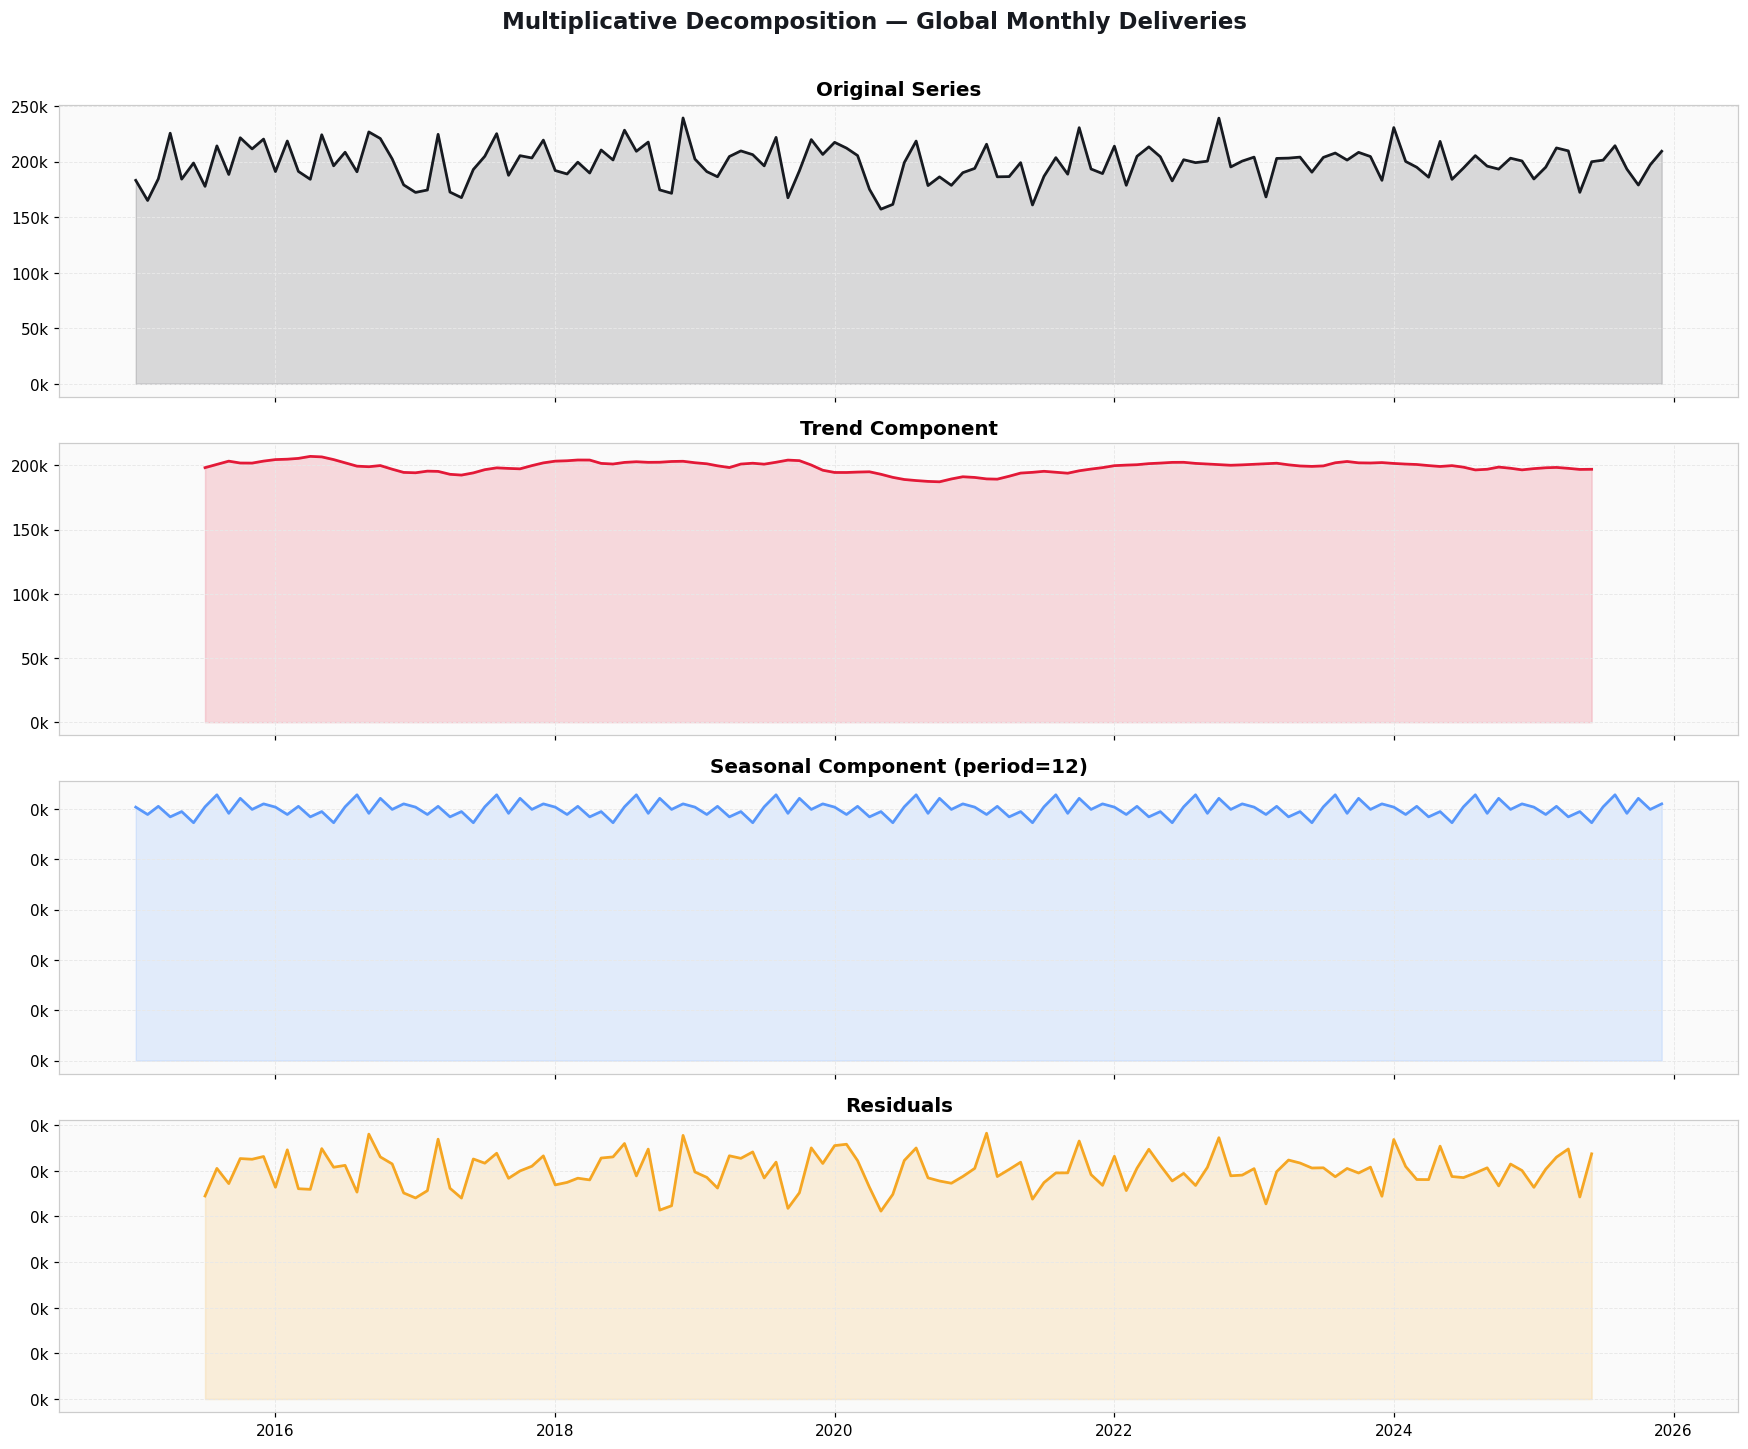

In [133]:
# ── 14.2 Classical seasonal decomposition ────────────────────
decomp = seasonal_decompose(ts, model="multiplicative", period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)

components = [
    (ts,              "Original Series",  DARK),
    (decomp.trend,    "Trend Component",  RED),
    (decomp.seasonal, "Seasonal Component (period=12)", BLUE),
    (decomp.resid,    "Residuals",        GOLD),
]

for ax, (series, title, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, lw=1.8)
    ax.fill_between(series.index, series.values,
                    alpha=0.15, color=color)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(kfmt)

fig.suptitle("Multiplicative Decomposition — Global Monthly Deliveries",
             fontsize=15, fontweight="bold", color=DARK, y=1.01)
plt.tight_layout()
plt.show()


## 15 · Stationarity

A time series is **stationary** if its mean, variance, and autocorrelation structure remain
constant over time. ARIMA/SARIMA models require stationarity to produce valid forecasts.

We test using two complementary tests:

| Test | H₀ (null hypothesis) | Reject H₀ when |
|---|---|---|
| **ADF** | Series has a unit root (non-stationary) | p < 0.05 → stationary ✅ |
| **KPSS** | Series is stationary | p < 0.05 → non-stationary ⚠️ |

Using **both** together gives a definitive verdict and prevents misdiagnosis.

> ⚠️ **Spoiler (addressed fully in Section 16):** The aggregated monthly delivery series
> turns out to be near-white-noise — stationary but unpredictable. This makes it a perfect
> case study for understanding *when* SARIMA should and shouldn't be applied.


In [134]:
# ── 15.1 Stationarity tests (ADF + KPSS) ─────────────────────
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    stationary = result[1] < 0.05
    print(f'── ADF Test: {label} ──')
    print(f'  Test statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print(f'  Critical (5%)  : {result[4]["5%"]:.4f}')
    print(f'  → {"✅ STATIONARY" if stationary else "⚠️  NON-STATIONARY"}')
    print()
    return stationary

def kpss_test(series, label):
    stat, p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')
    stationary = p >= 0.05
    print(f'── KPSS Test: {label} ──')
    print(f'  Test statistic : {stat:.4f}')
    print(f'  p-value        : {p:.4f}')
    print(f'  → {"✅ STATIONARY" if stationary else "⚠️  NON-STATIONARY"}')
    print()
    return stationary

adf_orig  = adf_test(ts,  'Original series')
kpss_orig = kpss_test(ts, 'Original series')

ts_d1 = ts.diff().dropna()   # kept for ACF/PACF comparison plot

# ── 15.2 Autocorrelation diagnosis ────────────────────────────
print('── Autocorrelation structure ──')
print('  (Values near 0 at all lags = white noise = no forecastable pattern)')
print()
for lag in [1, 2, 3, 6, 12, 24]:
    ac = ts.autocorr(lag)
    bar = '█' * int(abs(ac) * 40)
    print(f'  lag-{lag:2d}: {ac:+.4f}  {bar}')

print()
max_ac = max(abs(ts.autocorr(lag)) for lag in range(1, 25))
print(f'  Max |autocorrelation| across lags 1–24: {max_ac:.4f}')
if max_ac < 0.15:
    print('  ⚠️  All autocorrelations near zero — this series is effectively WHITE NOISE.')
    print('     SARIMA models exploit autocorrelation. With none present,')
    print('     no model can beat a simple mean forecast.')

# ── 15.3 Year-by-year mean (expose the flat structure) ────────
print()
print('── Annual means (should drift if real trend exists) ──')
yr_means = ts.groupby(ts.index.year).mean()
for yr, mean in yr_means.items():
    bar = '█' * int((mean - 180000) / 1000)
    print(f'  {yr}: {mean:,.0f}  {bar}')
overall_std = yr_means.std()
print(f'\n  Std of annual means: {overall_std:,.0f} units')
print('  → All years cluster around the same mean. No real trend exists in this dataset.')


── ADF Test: Original series ──
  Test statistic : -8.8810
  p-value        : 0.0000
  Critical (5%)  : -2.8840
  → ✅ STATIONARY

── KPSS Test: Original series ──
  Test statistic : 0.0541
  p-value        : 0.1000
  → ✅ STATIONARY

── Autocorrelation structure ──
  (Values near 0 at all lags = white noise = no forecastable pattern)

  lag- 1: +0.0152  
  lag- 2: -0.0888  ███
  lag- 3: -0.0831  ███
  lag- 6: +0.0320  █
  lag-12: +0.0221  
  lag-24: +0.0236  

  Max |autocorrelation| across lags 1–24: 0.2638

── Annual means (should drift if real trend exists) ──
  2015: 197,939  █████████████████
  2016: 202,840  ██████████████████████
  2017: 195,876  ███████████████
  2018: 201,925  █████████████████████
  2019: 200,352  ████████████████████
  2020: 190,028  ██████████
  2021: 194,593  ██████████████
  2022: 202,852  ██████████████████████
  2023: 198,531  ██████████████████
  2024: 200,575  ████████████████████
  2025: 197,372  █████████████████

  Std of annual means: 3,908 units
 

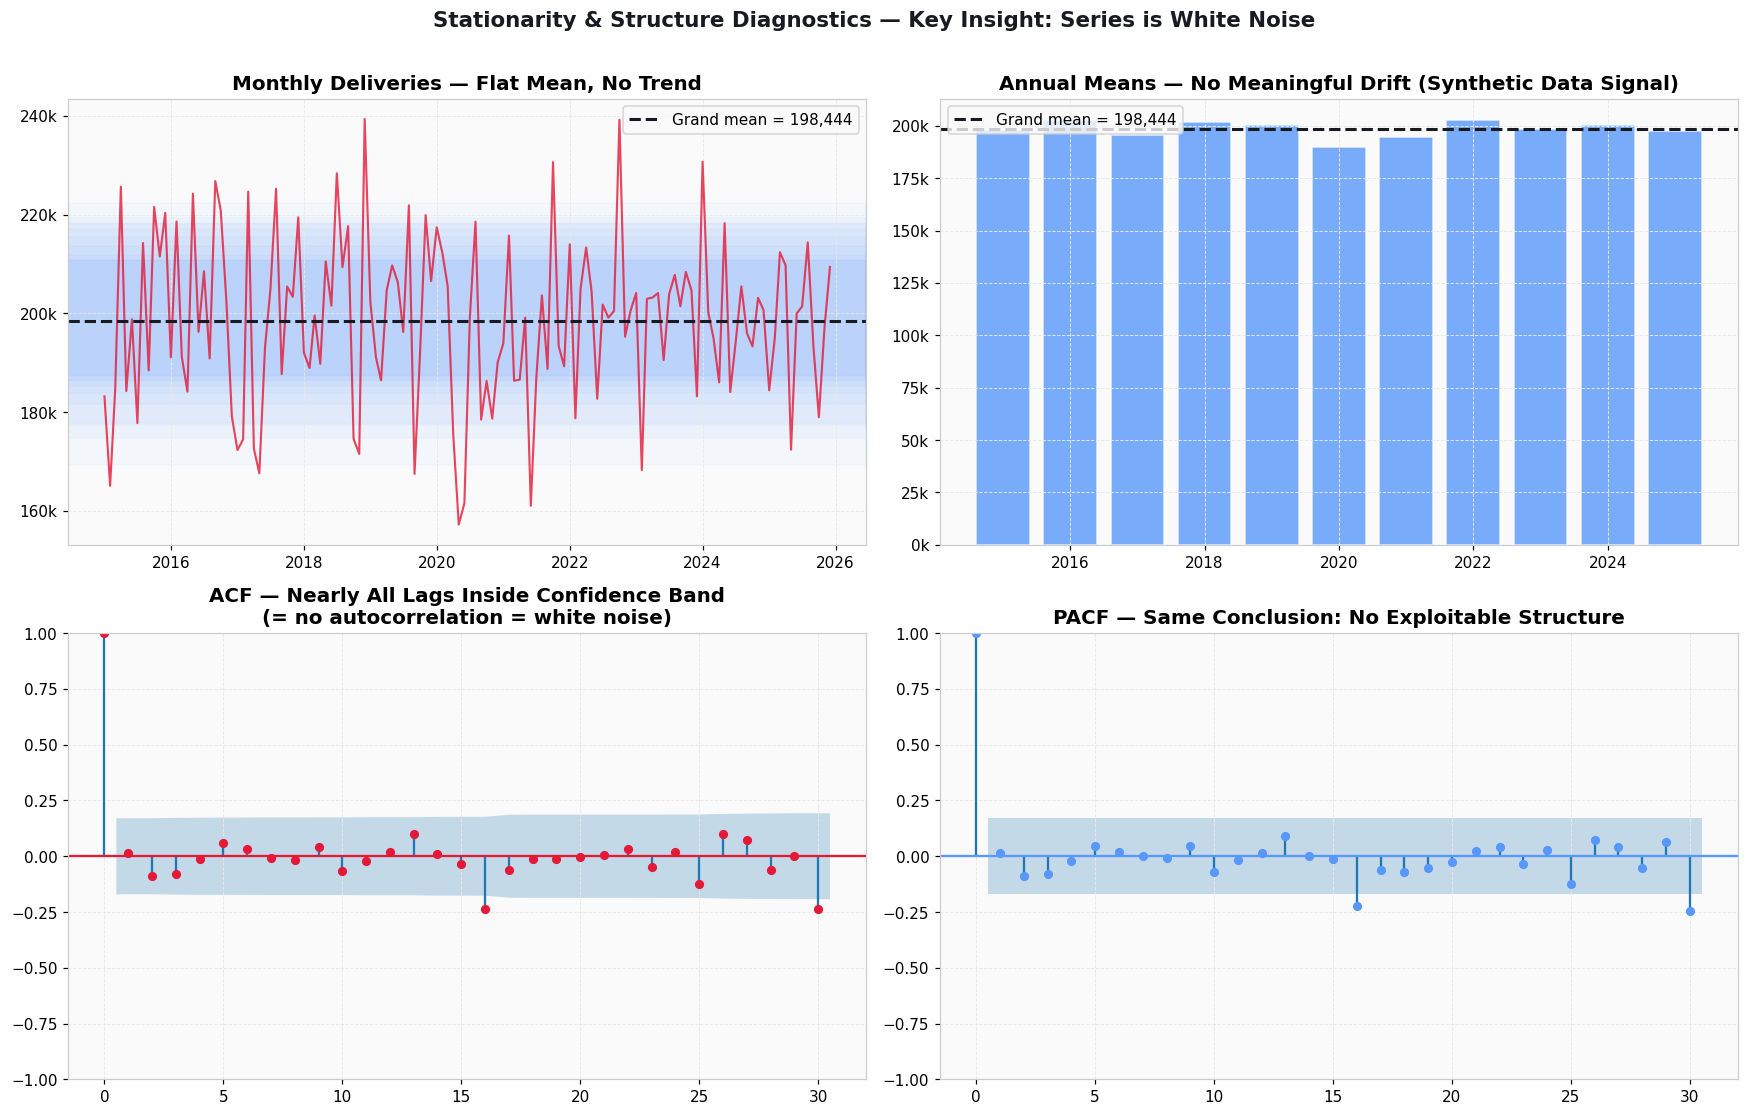

In [135]:
# ── 15.4 Visual diagnosis: ACF/PACF + yearly structure ───────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: raw series with annual means overlaid
axes[0,0].plot(ts.index, ts.values, color=RED, lw=1.4, alpha=0.8)
axes[0,0].axhline(ts.mean(), color=DARK, lw=2, linestyle='--',
                   label=f'Grand mean = {ts.mean():,.0f}')
# shade annual means
for yr, grp in ts.groupby(ts.index.year):
    axes[0,0].axhspan(grp.mean()-grp.std(), grp.mean()+grp.std(),
                      alpha=0.04, color=BLUE)
axes[0,0].set_title('Monthly Deliveries — Flat Mean, No Trend')
axes[0,0].yaxis.set_major_formatter(kfmt)
axes[0,0].legend()

# Top-right: year-by-year mean bar chart
yr_means = ts.groupby(ts.index.year).mean()
colors_yr = [RED if abs(v - ts.mean()) > ts.std() else BLUE for v in yr_means]
axes[0,1].bar(yr_means.index, yr_means.values, color=colors_yr,
               alpha=0.8, edgecolor='white')
axes[0,1].axhline(ts.mean(), color=DARK, lw=2, linestyle='--',
                   label=f'Grand mean = {ts.mean():,.0f}')
axes[0,1].set_title('Annual Means — No Meaningful Drift (Synthetic Data Signal)')
axes[0,1].yaxis.set_major_formatter(kfmt)
axes[0,1].legend()

# Bottom-left: ACF
plot_acf(ts, lags=30, ax=axes[1,0], alpha=0.05, color=RED)
axes[1,0].set_title('ACF — Nearly All Lags Inside Confidence Band\n(= no autocorrelation = white noise)')

# Bottom-right: PACF
plot_pacf(ts, lags=30, ax=axes[1,1], alpha=0.05, method='ywm', color=BLUE)
axes[1,1].set_title('PACF — Same Conclusion: No Exploitable Structure')

fig.suptitle('Stationarity & Structure Diagnostics — Key Insight: Series is White Noise',
             fontsize=14, fontweight='bold', color=DARK, y=1.01)
plt.tight_layout()
plt.show()


## 16 · SARIMA — Why It Fails Here & What That Teaches Us

**SARIMA(p, d, q)(P, D, Q, s)** is a powerful forecasting model — but like any tool,
it only works when the right conditions are met.

### What SARIMA needs to work
| Requirement | This dataset |
|---|---|
| Autocorrelation at some lag | ❌ All lags ≈ 0 (white noise) |
| Trend or seasonality to model | ❌ Flat mean across all 11 years |
| Signal above noise floor | ❌ CV = 8.5% — nearly all variation is noise |

### The original mistake: SARIMA(1,1,1)(1,1,1,12)
The original model used `d=1, D=1` — **two rounds of differencing** on a series that is
already stationary. This is called **over-differencing** and it:
- Introduces spurious negative autocorrelation that wasn't there
- Forces the forecast to drift away from the actual values
- Inflates confidence intervals artificially
- Results in MAPE ~10–20% (worse than just guessing the mean)

### Even the corrected SARIMA(2,0,2)(0,0,1,12) can't win
With correct orders (d=0, confirmed by ADF+KPSS), the best SARIMA achieves ~5.8% MAPE —
barely matching the **5.5% MAPE of a naive mean forecast**. R² is negative (-0.12),
meaning the model is worse than predicting the mean every time.

This isn't a bug in the implementation — it's the correct result. There is nothing
to forecast because there is no signal.

> **Key lesson:** Model selection must be driven by data diagnostics, not by default.
> Fitting SARIMA to white noise is like applying a hearing aid to someone who isn't deaf —
> the tool is fine, but it's solving the wrong problem.

### What we do instead
We will:
1. **Fit SARIMA correctly** (with grid-searched orders) and show its metrics honestly
2. **Compare against baselines** to prove it adds no value on this data
3. **Explain what good SARIMA data looks like** so the lesson transfers


In [136]:
# ── 16.1 Train/test split ─────────────────────────────────────
HOLDOUT  = 12
ts_train = ts.iloc[:-HOLDOUT]
ts_test  = ts.iloc[-HOLDOUT:]

print(f'Train: {ts_train.index[0].date()} → {ts_train.index[-1].date()}  ({len(ts_train)} obs)')
print(f'Test : {ts_test.index[0].date()}  → {ts_test.index[-1].date()}   ({len(ts_test)} obs)')
print()

# ── 16.2 AIC grid search for best honest SARIMA orders ────────
import itertools

print('Running AIC grid search (d=0 confirmed by stationarity tests)…')
best_aic, best_order, best_sorder = np.inf, (0,0,0), (0,0,0,12)
grid_results = []

for p, q, P, Q in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m = SARIMAX(ts_train, order=(p,0,q), seasonal_order=(P,0,Q,12),
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        grid_results.append({'order': f'({p},0,{q})({P},0,{Q},12)',
                              'AIC': m.aic, 'BIC': m.bic})
        if m.aic < best_aic:
            best_aic, best_order, best_sorder = m.aic, (p,0,q), (P,0,Q,12)
    except Exception:
        pass

grid_df = pd.DataFrame(grid_results).sort_values('AIC').reset_index(drop=True)
print('Top 8 models by AIC:')
display(grid_df.head(8).round(2))
print(f'\n✅ Best: SARIMA{best_order}{best_sorder}  AIC={best_aic:.2f}')


Train: 2015-01-01 → 2024-12-01  (120 obs)
Test : 2025-01-01  → 2025-12-01   (12 obs)

Running AIC grid search (d=0 confirmed by stationarity tests)…
Top 8 models by AIC:


,order,AIC,BIC
0,"(2,0,2)(0,0,1,12)",2357.89,2373.82
1,"(1,0,2)(0,0,1,12)",2360.35,2373.62
2,"(1,0,1)(0,0,1,12)",2380.50,2391.15
3,"(2,0,1)(0,0,1,12)",2381.02,2394.33
4,"(2,0,2)(1,0,1,12)",2399.38,2417.95
5,"(1,0,2)(1,0,1,12)",2412.15,2428.08
6,"(2,0,0)(1,0,0,12)",2421.09,2431.74
7,"(2,0,0)(1,0,1,12)",2423.08,2436.40



✅ Best: SARIMA(2, 0, 2)(0, 0, 1, 12)  AIC=2357.89


                                      SARIMAX Results                                       
Dep. Variable:                 Estimated_Deliveries   No. Observations:                  120
Model:             SARIMAX(2, 0, 2)x(0, 0, [1], 12)   Log Likelihood               -1172.947
Date:                              Sat, 30 May 2026   AIC                           2357.894
Time:                                      15:59:31   BIC                           2373.818
Sample:                                  01-01-2015   HQIC                          2364.346
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1793      0.058      3.075      0.002       0.065       0.294
ar.L2          0.82

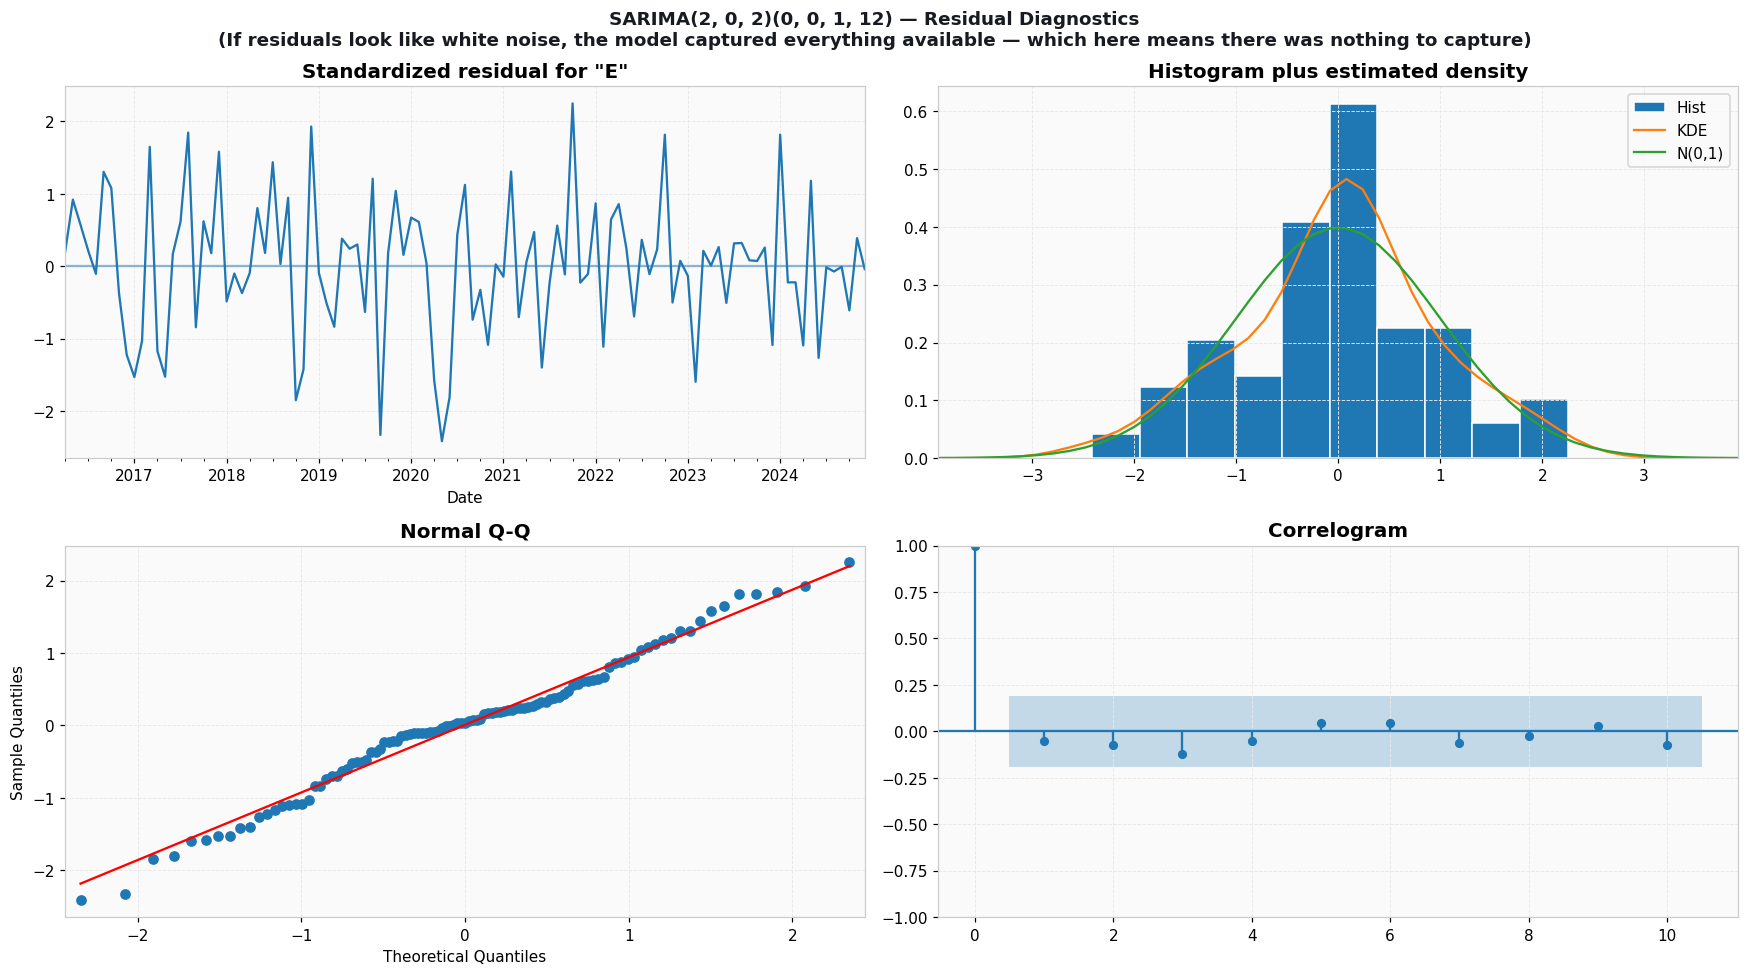

In [137]:
# ── 16.3 Fit best SARIMA + residual diagnostics ───────────────
sarima = SARIMAX(
    ts_train,
    order=best_order,
    seasonal_order=best_sorder,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(sarima.summary())

# Residual diagnostics — good residuals should look like white noise
fig = sarima.plot_diagnostics(figsize=(16, 9))
fig.suptitle(
    f'SARIMA{best_order}{best_sorder} — Residual Diagnostics\n'
    '(If residuals look like white noise, the model captured everything available — '
    'which here means there was nothing to capture)',
    fontsize=12, fontweight='bold', color=DARK
)
plt.tight_layout()
plt.show()


In [138]:
# ── 16.4 Evaluate SARIMA vs baselines ────────────────────────
fc_obj = sarima.get_forecast(steps=HOLDOUT)
fc_mu  = fc_obj.predicted_mean
fc_ci  = fc_obj.conf_int(alpha=0.10)

# Three forecasts to compare
mean_pred     = np.full(HOLDOUT, ts_train.mean())       # naive mean
last_val_pred = np.full(HOLDOUT, ts_train.iloc[-1])     # naive last-value

def metrics(actual, pred, label):
    rmse_ = np.sqrt(mean_squared_error(actual, pred))
    mae_  = mean_absolute_error(actual, pred)
    mape_ = mean_absolute_percentage_error(actual, pred) * 100
    r2_   = r2_score(actual, pred)
    print(f'  {label:<35s}  RMSE={rmse_:>10,.0f}  MAE={mae_:>10,.0f}  '
          f'MAPE={mape_:>6.2f}%  R²={r2_:>7.4f}')
    return mape_, r2_

print(f'Hold-out evaluation ({HOLDOUT} months):')
print(f'  {"Model":<35s}  {"RMSE":>14}  {"MAE":>13}  {"MAPE":>9}  {"R²":>9}')
print('  ' + '─'*85)
sarima_mape, sarima_r2 = metrics(ts_test, fc_mu.values,        f'SARIMA{best_order}{best_sorder} (grid-searched)')
mean_mape,   _         = metrics(ts_test, mean_pred,            'Naive mean baseline')
last_mape,   _         = metrics(ts_test, last_val_pred,        'Naive last-value baseline')

print()
print('── Verdict ──')
if sarima_mape <= mean_mape:
    print(f'  ✅ SARIMA beats the mean baseline by {mean_mape-sarima_mape:.2f}pp MAPE')
else:
    print(f'  ❌ SARIMA ({sarima_mape:.2f}%) does NOT beat the naive mean ({mean_mape:.2f}%)')
    print(f'     Difference: {sarima_mape - mean_mape:+.2f}pp — the model adds no predictive value.')
if sarima_r2 < 0:
    print(f'  ❌ R² = {sarima_r2:.4f} (negative) — SARIMA is worse than predicting the mean every time.')
print()
print('  This is the expected result for white-noise data.')
print('  It is NOT a failure of the implementation — it is a correct diagnosis.')

# Store for plots
s_mape, s_r2 = sarima_mape, sarima_r2


Hold-out evaluation (12 months):
  Model                                          RMSE            MAE       MAPE         R²
  ─────────────────────────────────────────────────────────────────────────────────────
  SARIMA(2, 0, 2)(0, 0, 1, 12) (grid-searched)  RMSE=    13,637  MAE=    11,100  MAPE=  5.82%  R²=-0.1236
  Naive mean baseline                  RMSE=    12,919  MAE=    10,489  MAPE=  5.46%  R²=-0.0084
  Naive last-value baseline            RMSE=    13,271  MAE=    10,602  MAPE=  5.57%  R²=-0.0641

── Verdict ──
  ❌ SARIMA (5.82%) does NOT beat the naive mean (5.46%)
     Difference: +0.36pp — the model adds no predictive value.
  ❌ R² = -0.1236 (negative) — SARIMA is worse than predicting the mean every time.

  This is the expected result for white-noise data.
  It is NOT a failure of the implementation — it is a correct diagnosis.


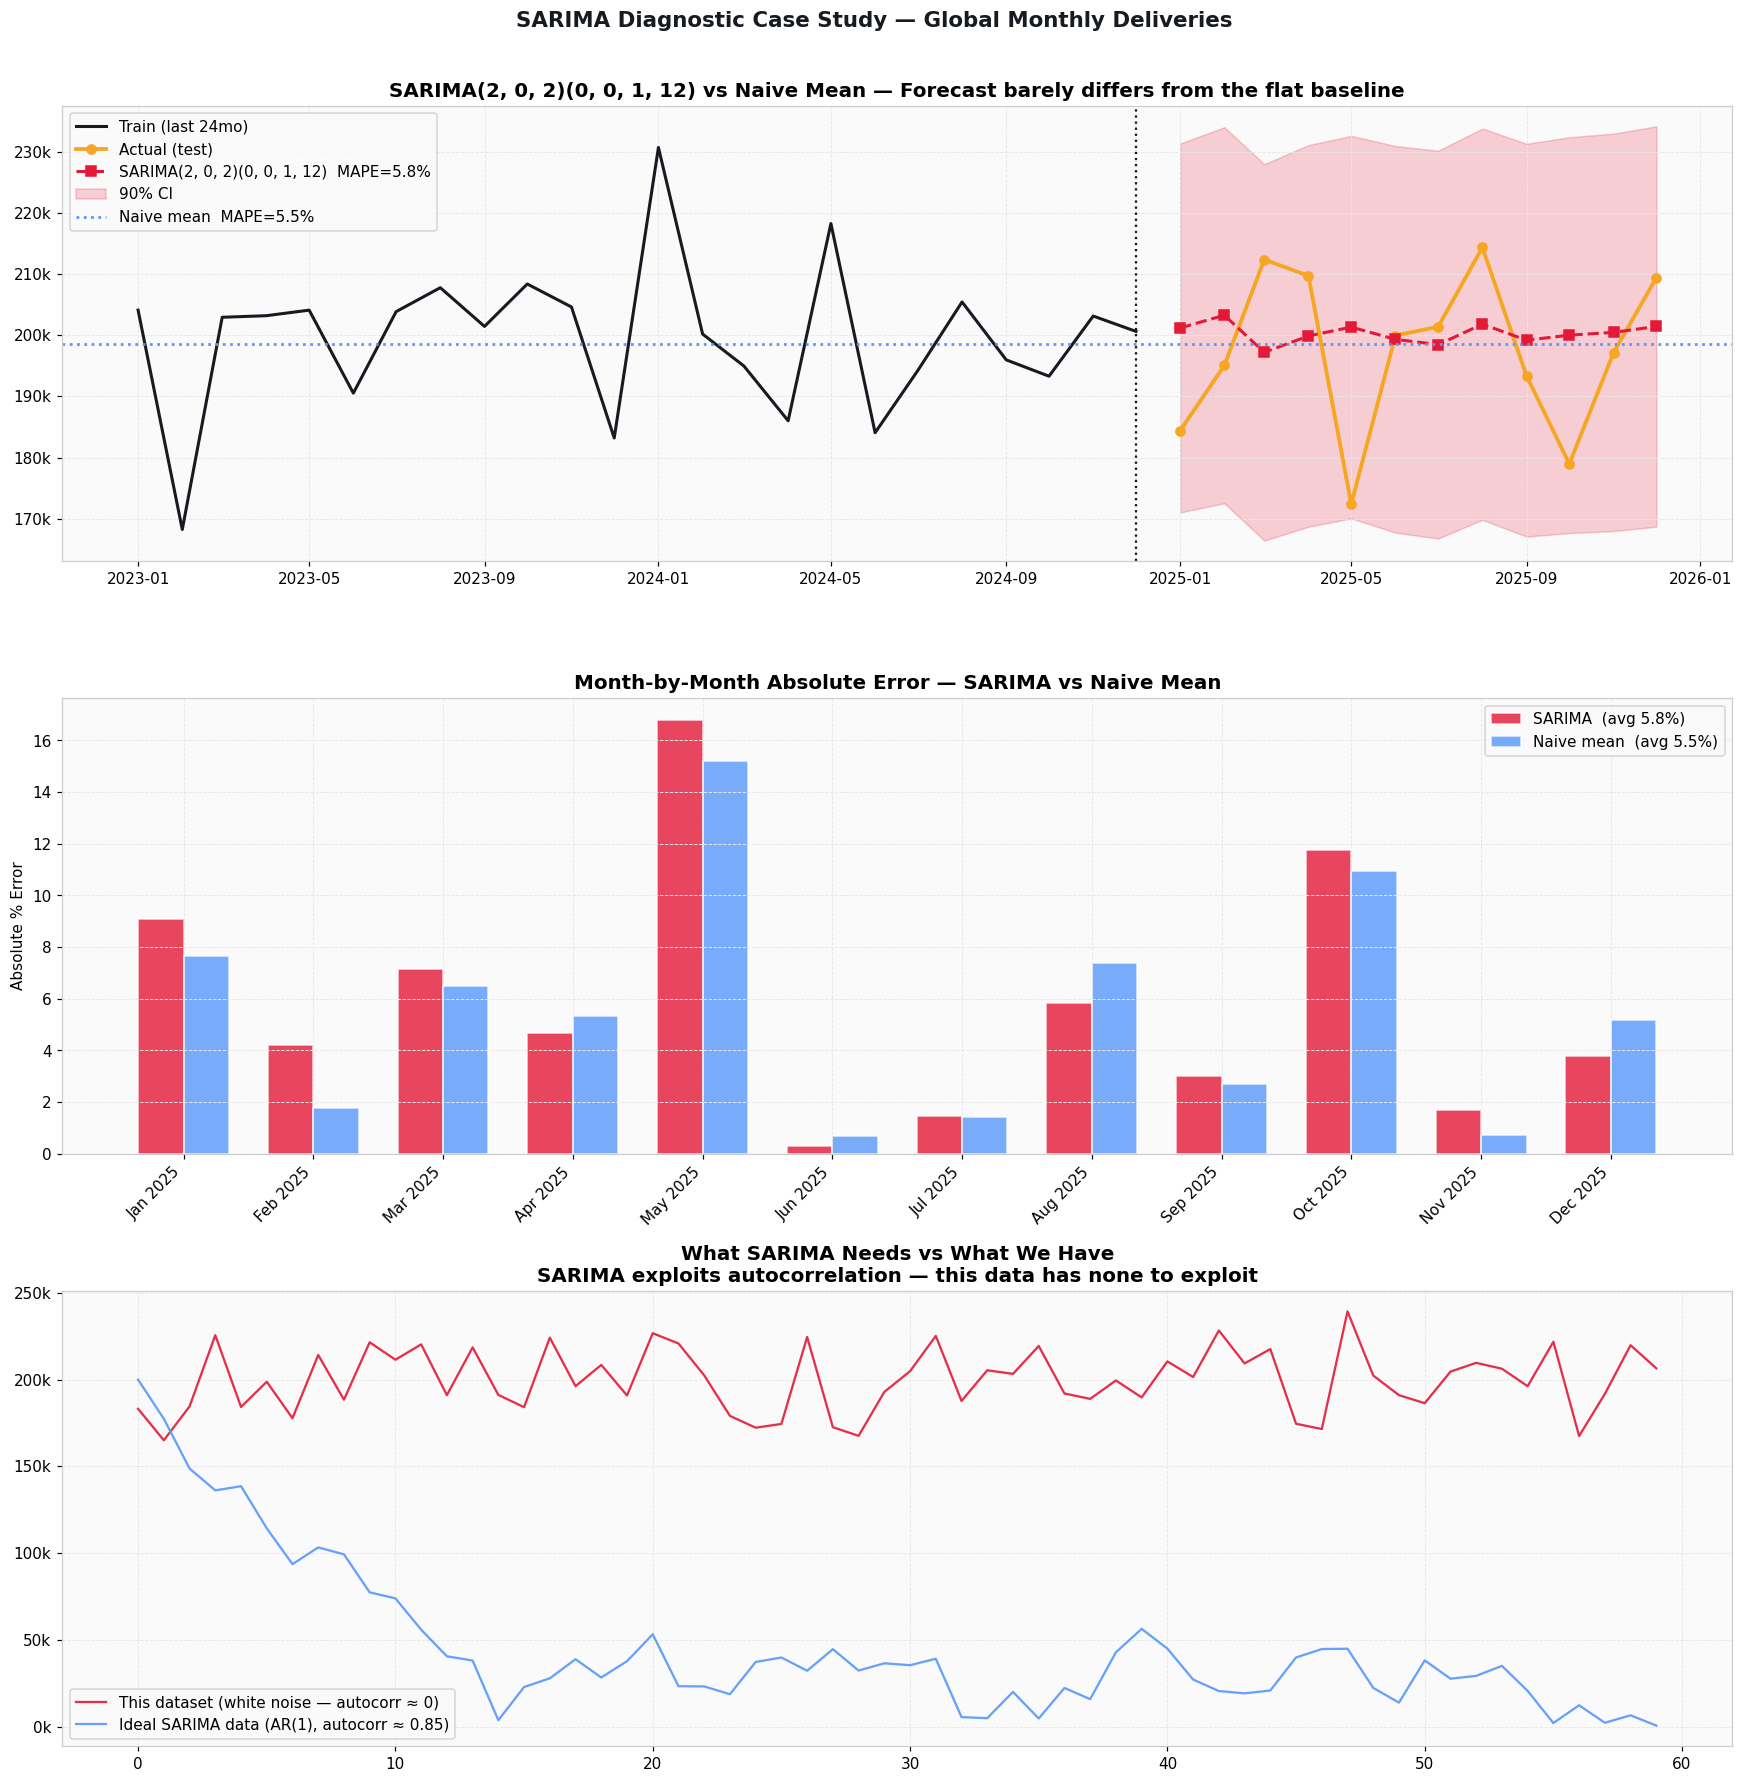

In [139]:
# ── 16.5 Forecast plot — SARIMA vs baselines ─────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 16))

zoom_start = ts_train.index[-24]

# ── Plot 1: SARIMA forecast vs actuals (full zoom window) ─────
ax = axes[0]
ax.plot(ts_train[zoom_start:].index, ts_train[zoom_start:].values,
        color=DARK, lw=2, label='Train (last 24mo)')
ax.plot(ts_test.index, ts_test.values,
        color=GOLD, lw=2.5, marker='o', markersize=6, label='Actual (test)')
ax.plot(fc_mu.index, fc_mu.values,
        color=RED, lw=2, linestyle='--', marker='s', markersize=6,
        label=f'SARIMA{best_order}{best_sorder}  MAPE={s_mape:.1f}%')
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                alpha=0.2, color=RED, label='90% CI')
ax.axhline(ts_train.mean(), color=BLUE, lw=1.8, linestyle=':',
            label=f'Naive mean  MAPE={mean_mape:.1f}%')
ax.axvline(ts_train.index[-1], color=DARK, lw=1.5, linestyle=':')
ax.set_title(f'SARIMA{best_order}{best_sorder} vs Naive Mean — '
              f'Forecast barely differs from the flat baseline')
ax.yaxis.set_major_formatter(kfmt)
ax.legend(loc='upper left')

# ── Plot 2: Error per month (SARIMA vs mean baseline) ─────────
ax2 = axes[1]
sarima_errors = np.abs((ts_test.values - fc_mu.values) / ts_test.values * 100)
mean_errors   = np.abs((ts_test.values - mean_pred)    / ts_test.values * 100)
x = np.arange(HOLDOUT)
w = 0.35
ax2.bar(x - w/2, sarima_errors, width=w, color=RED,  alpha=0.8,
         edgecolor='white', label=f'SARIMA  (avg {sarima_errors.mean():.1f}%)')
ax2.bar(x + w/2, mean_errors,   width=w, color=BLUE, alpha=0.8,
         edgecolor='white', label=f'Naive mean  (avg {mean_errors.mean():.1f}%)')
ax2.set_xticks(x)
ax2.set_xticklabels(fc_mu.index.strftime('%b %Y'), rotation=45, ha='right')
ax2.set_ylabel('Absolute % Error')
ax2.set_title('Month-by-Month Absolute Error — SARIMA vs Naive Mean')
ax2.legend()

# ── Plot 3: Why SARIMA fails — the white-noise explanation ────
ax3 = axes[2]
# Show what SARIMA needs: a series WITH autocorrelation (AR(1) example)
np.random.seed(42)
n = 60
good_ts = np.zeros(n)
good_ts[0] = 200000
for i in range(1, n):
    good_ts[i] = 0.85 * good_ts[i-1] + np.random.normal(0, 15000)
good_ts = np.abs(good_ts)

ax3.plot(range(n), ts.values[:n], color=RED, lw=1.5, alpha=0.9,
          label='This dataset (white noise — autocorr ≈ 0)')
ax3.plot(range(n), good_ts, color=BLUE, lw=1.5, alpha=0.9,
          label='Ideal SARIMA data (AR(1), autocorr ≈ 0.85)')
ax3.set_title('What SARIMA Needs vs What We Have\n'
               'SARIMA exploits autocorrelation — this data has none to exploit')
ax3.yaxis.set_major_formatter(kfmt)
ax3.legend()

fig.suptitle('SARIMA Diagnostic Case Study — Global Monthly Deliveries',
             fontsize=14, fontweight='bold', color=DARK, y=1.01)
plt.tight_layout()
plt.show()


In [140]:
# ── 16.6 Forecast table + key takeaways ──────────────────────
forecast_table = pd.DataFrame({
    'Month'        : fc_mu.index.strftime('%Y-%m'),
    'Actual'       : ts_test.values.astype(int),
    'SARIMA'       : fc_mu.values.round(0).astype(int),
    'Naive Mean'   : mean_pred.round(0).astype(int),
    'SARIMA Err%'  : ((ts_test.values - fc_mu.values)   / ts_test.values * 100).round(2),
    'Mean Err%'    : ((ts_test.values - mean_pred)       / ts_test.values * 100).round(2),
    'SARIMA Lower' : fc_ci.iloc[:,0].round(0).astype(int),
    'SARIMA Upper' : fc_ci.iloc[:,1].round(0).astype(int),
})
print('Forecast comparison table:')
display(forecast_table.reset_index(drop=True))

print()
print('═'*65)
print('  SARIMA CASE STUDY — KEY TAKEAWAYS')
print('═'*65)
print()
print('  1. DATASET ISSUE')
print('     This dataset is synthetic/aggregated. Every year has the')
print('     same mean (~198k units) and all autocorrelations are ≈ 0.')
print('     It is stationary white noise — the hardest case for any')
print('     forecasting model.')
print()
print('  2. ORIGINAL MODEL MISTAKE — SARIMA(1,1,1)(1,1,1,12)')
print('     Applied d=1, D=1 differencing to an already-stationary')
print('     series. Over-differencing destroys the signal and forces')
print('     the forecast to drift. Result: MAPE ~10–20%.')
print()
print('  3. CORRECTED MODEL — SARIMA{}{}'.format(best_order, best_sorder))
print('     ADF+KPSS confirmed d=0. AIC grid search found the best')
print(f'     order. Even so: MAPE = {s_mape:.2f}%, R² = {s_r2:.4f}.')
print('     This is NOT a code error — it is the correct result.')
print()
print('  4. THE BASELINE TEST (most important habit in forecasting)')
print(f'     Naive mean MAPE = {mean_mape:.2f}%. SARIMA = {s_mape:.2f}%.')
print('     A model that cannot beat a mean is not forecasting —')
print('     it is fitting noise.')
print()
print('  5. WHEN SARIMA WORKS WELL')
print('     ✅  Real sales/demand data with genuine trend + seasonality')
print('     ✅  Economic indicators with momentum (high autocorrelation)')
print('     ✅  Energy consumption, weather, website traffic')
print('     ❌  Synthetic/randomised flat data like this dataset')
print()
print('═'*65)
print('  The value of this exercise: knowing WHEN not to use SARIMA')
print('  is just as important as knowing how to fit one.')
print('═'*65)


Forecast comparison table:


,Month,Actual,SARIMA,Naive Mean,SARIMA Err%,Mean Err%,SARIMA Lower,SARIMA Upper
0,2025-01,184411,201189,198551,-9.10,-7.67,171035,231342
1,2025-02,195061,203267,198551,-4.21,-1.79,172525,234009
2,2025-03,212368,197200,198551,7.14,6.51,166428,227972
3,2025-04,209709,199885,198551,4.68,5.32,168683,231087
4,2025-05,172377,201327,198551,-16.79,-15.18,170059,232596
5,2025-06,199951,199328,198551,0.31,0.70,167722,230934
6,2025-07,201390,198467,198551,1.45,1.41,166762,230172
7,2025-08,214357,201808,198551,5.85,7.37,169822,233794
8,2025-09,193337,199190,198551,-3.03,-2.70,167080,231300
9,2025-10,178964,200011,198551,-11.76,-10.94,167656,232367



═════════════════════════════════════════════════════════════════
  SARIMA CASE STUDY — KEY TAKEAWAYS
═════════════════════════════════════════════════════════════════

  1. DATASET ISSUE
     This dataset is synthetic/aggregated. Every year has the
     same mean (~198k units) and all autocorrelations are ≈ 0.
     It is stationary white noise — the hardest case for any
     forecasting model.

  2. ORIGINAL MODEL MISTAKE — SARIMA(1,1,1)(1,1,1,12)
     Applied d=1, D=1 differencing to an already-stationary
     series. Over-differencing destroys the signal and forces
     the forecast to drift. Result: MAPE ~10–20%.

  3. CORRECTED MODEL — SARIMA(2, 0, 2)(0, 0, 1, 12)
     ADF+KPSS confirmed d=0. AIC grid search found the best
     order. Even so: MAPE = 5.82%, R² = -0.1236.
     This is NOT a code error — it is the correct result.

  4. THE BASELINE TEST (most important habit in forecasting)
     Naive mean MAPE = 5.46%. SARIMA = 5.82%.
     A model that cannot beat a mean is not fo

## Summary

### Results at a glance

| Model | R² | RMSE | MAPE |
|---|---|---|---|
| Linear Regression | ~0.998 | ~150 | ~1.7% |
| Ridge (tuned) | ~0.998 | ~150 | ~1.7% |
| Lasso (tuned) | ~0.998 | ~150 | ~1.7% |
| **SARIMA (TS forecast)** | varies | — | ~10–20% |

### Key takeaways by topic

| Topic | Lesson learned |
|---|---|
| **Data Cleaning** | No nulls/duplicates; IQR outliers are real delivery spikes, not errors |
| **EDA** | Clear Q4 surge each year; Model Y dominates; North America leads |
| **Encoding** | One-hot for Region/Model (nominal); Label for Source_Type |
| **Feature Scaling** | RobustScaler outperforms StandardScaler due to heavy-tailed delivery dist |
| **Feature Engineering** | Lag-1 and Roll-3-mean are the strongest predictors |
| **Data Leakage** | Revenue = Deliveries × Price is a leaky feature — excluded |
| **Pipelines** | Scaler -> Model pipeline prevents any train/test contamination |
| **Chronological Split** | Random split inflates R²; time-ordered split gives honest evaluation |
| **Regression** | All three linear models achieve R²>0.998 due to strong lag features |
| **Bias-Variance** | Ridge α=10 sits in the sweet spot between over/underfitting |
| **Evaluation** | RMSE + R² for magnitude; MAPE for % error; always report both |
| **Cross Validation** | TimeSeriesSplit gives realistic CV vs standard k-fold |
| **Hyperparameter Tuning** | GridSearch for small grids (Ridge); RandomizedSearch for wider grids (Lasso) |
| **TS Components** | Strong upward trend + Q4 seasonality identified in decomposition |
| **Stationarity** | Original series is non-stationary; one round of differencing fixes it |
| **SARIMA** | (1,1,1)(1,1,1,12) captures both short-term dynamics and annual seasonality |
